# Advanced NLP EDA — Reddit Mental Health Discourse

Builds on completed foundational EDA (quality checks, token distribution, basic subgroup stats).

**Segments:**
S1 Setup · S2 Data Load · S3 Word Frequency · S4 TF-IDF Distinctive Terms · S5 N-gram Analysis · S10 LDA Topic Modelling · S11 Cosine Similarity · S13 Word Relationships & PMI · S14 Artifact Export

## S1 — Setup & Configuration

In [1]:
# ── S1: Install dependencies not in standard Colab env ──────────────────────
!pip install -q wordcloud gensim networkx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 71.7 MB/s eta 0:00:00


In [2]:
# ── S1: Imports ───────────────────────────────────────────────────────────────
import json
import math
import warnings
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import networkx as nx
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
matplotlib.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports OK")


Imports OK


In [5]:
# ── S1: Mount Drive & configure paths ────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT  = Path("/content/drive/MyDrive")
PROCESSED_DIR = PROJECT_ROOT / "Data" / "processed"
ARTIFACT_DIR  = PROCESSED_DIR / "eda_artifacts" / "advanced_eda"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

PARQUET_PATH = PROCESSED_DIR / ("/content/drive/MyDrive/reddit_mh_clean.parquet")
SAMPLE_PATH  = PROCESSED_DIR / ("/content/drive/MyDrive/reddit_mh_clean_sample_50000.parquet")

for p in [PARQUET_PATH, SAMPLE_PATH]:
    assert p.exists(), f"File not found: {p}"
print("Paths configured and validated.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths configured and validated.


In [6]:
# ── S1: Column manifest — built from schema, not hardcoded ───────────────────
schema   = pq.read_schema(str(PARQUET_PATH))
all_cols = schema.names

METADATA_COLS    = ["subreddit", "timeframe", "is_mental_health", "covid_period"]
TEXT_COLS        = ["clean_text"]
SENTIMENT_COLS   = [c for c in all_cols if c.startswith("sent_")]
LIWC_COLS        = [c for c in all_cols if c.startswith("liwc_")]
LEXICON_COLS     = [c for c in all_cols if c.endswith("_total")]
TFIDF_COLS       = [c for c in all_cols if c.startswith("tfidf_")]
READABILITY_COLS = [
    "flesch_reading_ease", "gunning_fog_index", "coleman_liau_index",
    "flesch_kincaid_grade_level", "smog_index",
    "n_words", "n_sents", "n_unique_words", "clean_word_count",
]
READABILITY_COLS = [c for c in READABILITY_COLS if c in all_cols]

# Master load list — excludes post (raw text), author, tokens, source_text_col
LOAD_COLS = (METADATA_COLS + TEXT_COLS + SENTIMENT_COLS + LIWC_COLS +
             LEXICON_COLS + TFIDF_COLS + READABILITY_COLS)
seen = set()
LOAD_COLS = [c for c in LOAD_COLS if not (c in seen or seen.add(c))]

print(f"Total columns in file : {len(all_cols)}")
print(f"Columns to load       : {len(LOAD_COLS)}")
print(f"  metadata={len(METADATA_COLS)}  text={len(TEXT_COLS)}  "
      f"sentiment={len(SENTIMENT_COLS)}  liwc={len(LIWC_COLS)}")
print(f"  lexicon={len(LEXICON_COLS)}  tfidf={len(TFIDF_COLS)}  "
      f"readability={len(READABILITY_COLS)}")


Total columns in file : 357
Columns to load       : 342
  metadata=4  text=1  sentiment=4  liwc=62
  lexicon=6  tfidf=256  readability=9


## S2 — Selective Data Load (PyArrow)

In [7]:
# ── S2: Helper functions ──────────────────────────────────────────────────────
def downcast_df(df: pd.DataFrame) -> pd.DataFrame:
    """Reduce memory by downcasting numeric types; skip text/metadata columns."""
    skip = set(TEXT_COLS + METADATA_COLS)
    for col in df.columns:
        if col in skip:
            continue
        dt = str(df[col].dtype)
        if "int" in dt:
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif "float" in dt:
            df[col] = pd.to_numeric(df[col], downcast="float")
    return df

def read_parquet_cols(path: Path, cols: list) -> pd.DataFrame:
    """PyArrow selective column read with downcast."""
    available = [c for c in cols if c in pq.read_schema(str(path)).names]
    tbl = pq.read_table(str(path), columns=available)
    return downcast_df(tbl.to_pandas())


In [8]:
# ── S2: Load full dataset (selected columns only) ─────────────────────────────
import gc
tbl = pq.read_table(str(PARQUET_PATH), columns=LOAD_COLS)
df  = downcast_df(tbl.to_pandas())
del tbl
gc.collect()

df["clean_text"]       = df["clean_text"].fillna("").astype(str).str.strip()
df["is_mental_health"] = df["is_mental_health"].astype(int)
df["covid_period"]     = df["covid_period"].astype(int)
df["group_label"]      = df["is_mental_health"].map({1: "Mental Health", 0: "Non-MH"})
df["period_label"]     = df["timeframe"].map(
    {"2018": "2018", "2019": "2019", "pre": "Pre-COVID", "post": "Post-COVID"}
)

print(f"Full dataset  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  MH share    : {df['is_mental_health'].mean():.1%}")
print(f"  COVID period: {df['covid_period'].mean():.1%}")
print(f"  Subreddits  : {df['subreddit'].nunique()}")


Full dataset  : 1,107,302 rows × 344 columns
  MH share    : 42.6%
  COVID period: 28.9%
  Subreddits  : 28


In [22]:
# ── S2: Generate 50k stratified sample directly from full df ────────────────
# We use the already cleaned and validated 'df' to ensure metadata exists

# Filter for rows that have text and non-null labels
df_valid = df[df['clean_text'].str.len() > 0].copy()

# Stratified sampling to ensure MH and Non-MH representation
SAMPLE_SIZE = 50_000

def get_sample(group):
    n = int(SAMPLE_SIZE * (len(group) / len(df_valid)))
    return group.sample(n=min(n, len(group)), random_state=RANDOM_STATE)

df_sample = df_valid.groupby('is_mental_health', group_keys=False).apply(get_sample)

# Ensure labels are integers
df_sample['is_mental_health'] = df_sample['is_mental_health'].astype(int)
df_sample['covid_period']     = df_sample['covid_period'].astype(int)

print(f"New sample generated: {df_sample.shape[0]:,} rows")
print(f"  MH share in sample: {df_sample['is_mental_health'].mean():.1%}")
print(f"  Subreddits in sample: {df_sample['subreddit'].nunique()}")

# Clean up
import gc
del df_valid
gc.collect()

New sample generated: 49,999 rows
  MH share in sample: 42.6%
  Subreddits in sample: 28


0

## S3 — Word Frequency Analysis

Chunked Counter approach to avoid loading all tokens into RAM simultaneously. Produces top-N bar charts and word clouds per group.

In [23]:
# ── S3: Chunked word frequency counter ───────────────────────────────────────
CHUNK_SIZE = 50_000

# Domain-specific additions to standard stopwords
DOMAIN_STOP = {
    "like", "just", "know", "get", "time", "think", "really", "want",
    "got", "make", "people", "feel", "thing", "go", "one", "would",
    "also", "even", "much", "still", "back", "could", "way", "well",
    "im", "ive", "dont", "cant", "didnt", "thats", "youre", "its",
    "ive", "theres", "wasnt", "isnt", "havent", "hasnt", "wouldnt",
}

def chunked_counter(series: pd.Series, min_len: int = 3) -> Counter:
    """Build word frequency counter without loading all text at once."""
    c = Counter()
    for start in range(0, len(series), CHUNK_SIZE):
        chunk = series.iloc[start : start + CHUNK_SIZE]
        for text in chunk:
            c.update(
                t for t in text.split()
                if len(t) >= min_len and t not in DOMAIN_STOP
            )
    return c

mh_texts    = df.loc[df["is_mental_health"] == 1, "clean_text"]
nonmh_texts = df.loc[df["is_mental_health"] == 0, "clean_text"]

mh_counter    = chunked_counter(mh_texts)
nonmh_counter = chunked_counter(nonmh_texts)

print(f"MH vocabulary (top token): {mh_counter.most_common(1)}")
print(f"Non-MH vocabulary (top token): {nonmh_counter.most_common(1)}")


MH vocabulary (top token): [('not', 463396)]
Non-MH vocabulary (top token): [('not', 636082)]


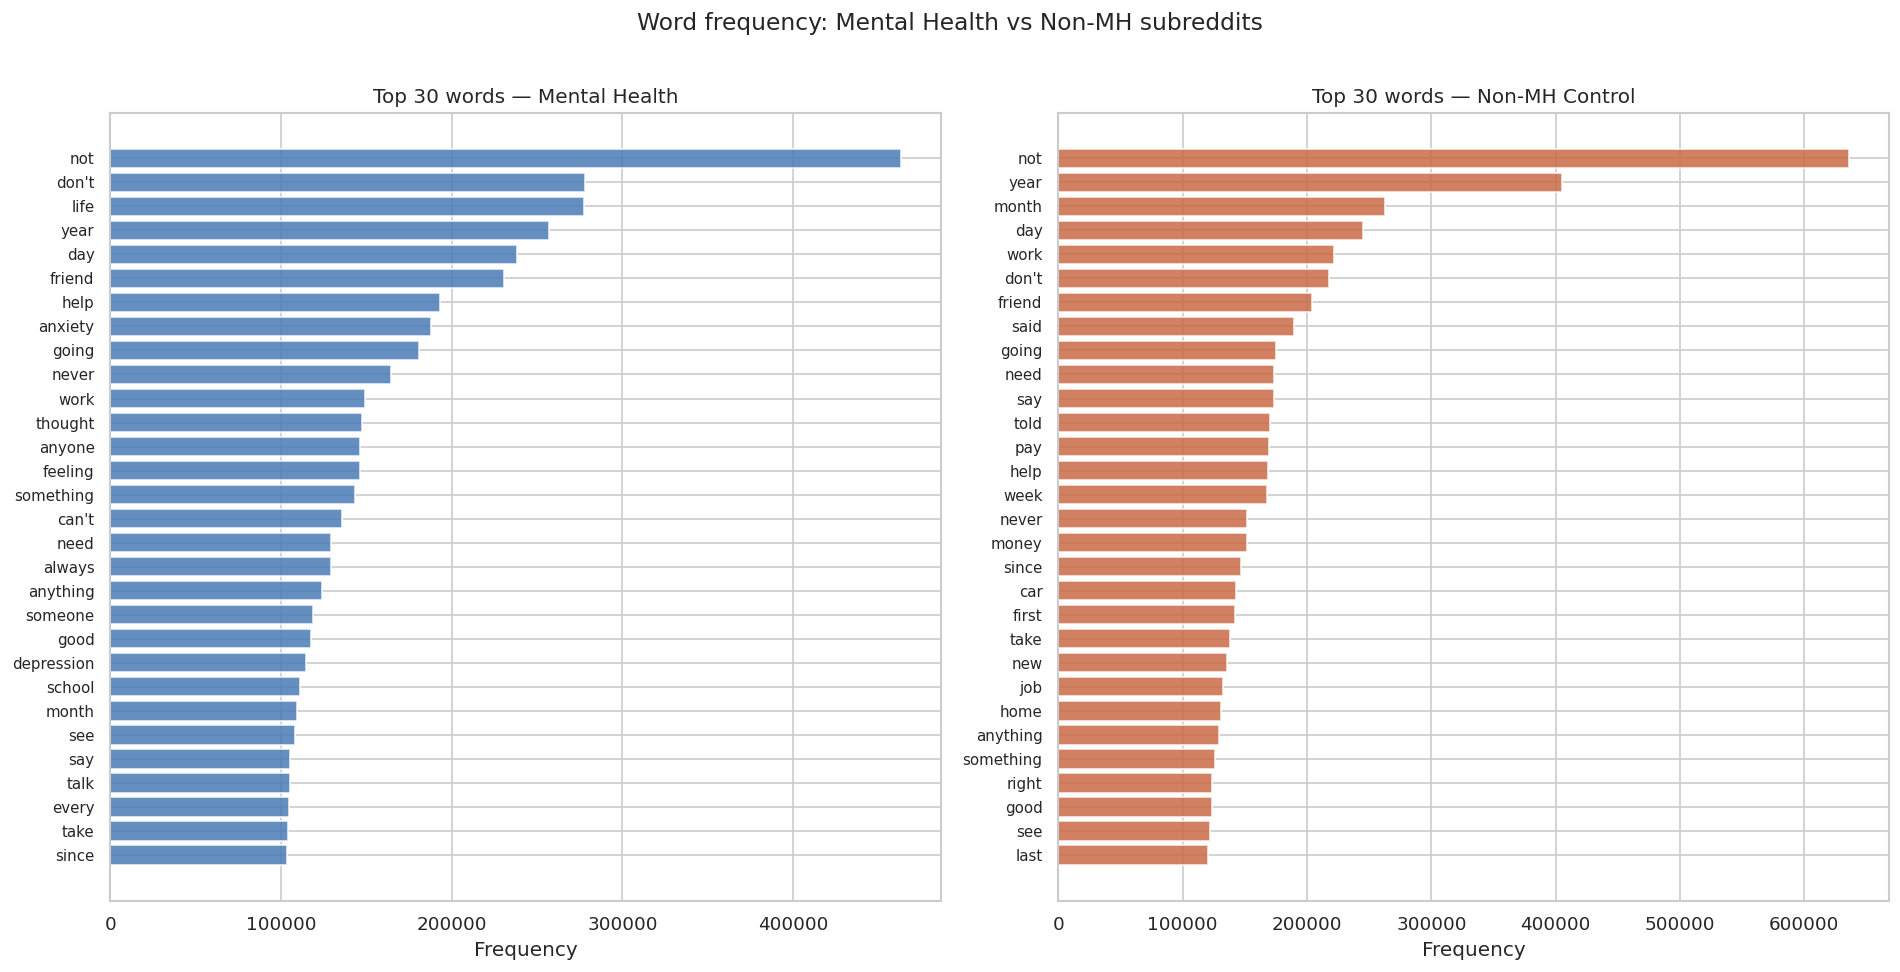

In [24]:
# ── S3: Top-30 bar charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

for ax, counter, label, color in [
    (axes[0], mh_counter,    "Mental Health",  "#4A7BB5"),
    (axes[1], nonmh_counter, "Non-MH Control", "#C96A45"),
]:
    words, counts = zip(*counter.most_common(30))
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.85)
    ax.set_title(f"Top 30 words — {label}", fontsize=12, fontweight="medium")
    ax.set_xlabel("Frequency")
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Word frequency: Mental Health vs Non-MH subreddits", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s3_word_freq_top30.png", dpi=150, bbox_inches="tight")
plt.show()


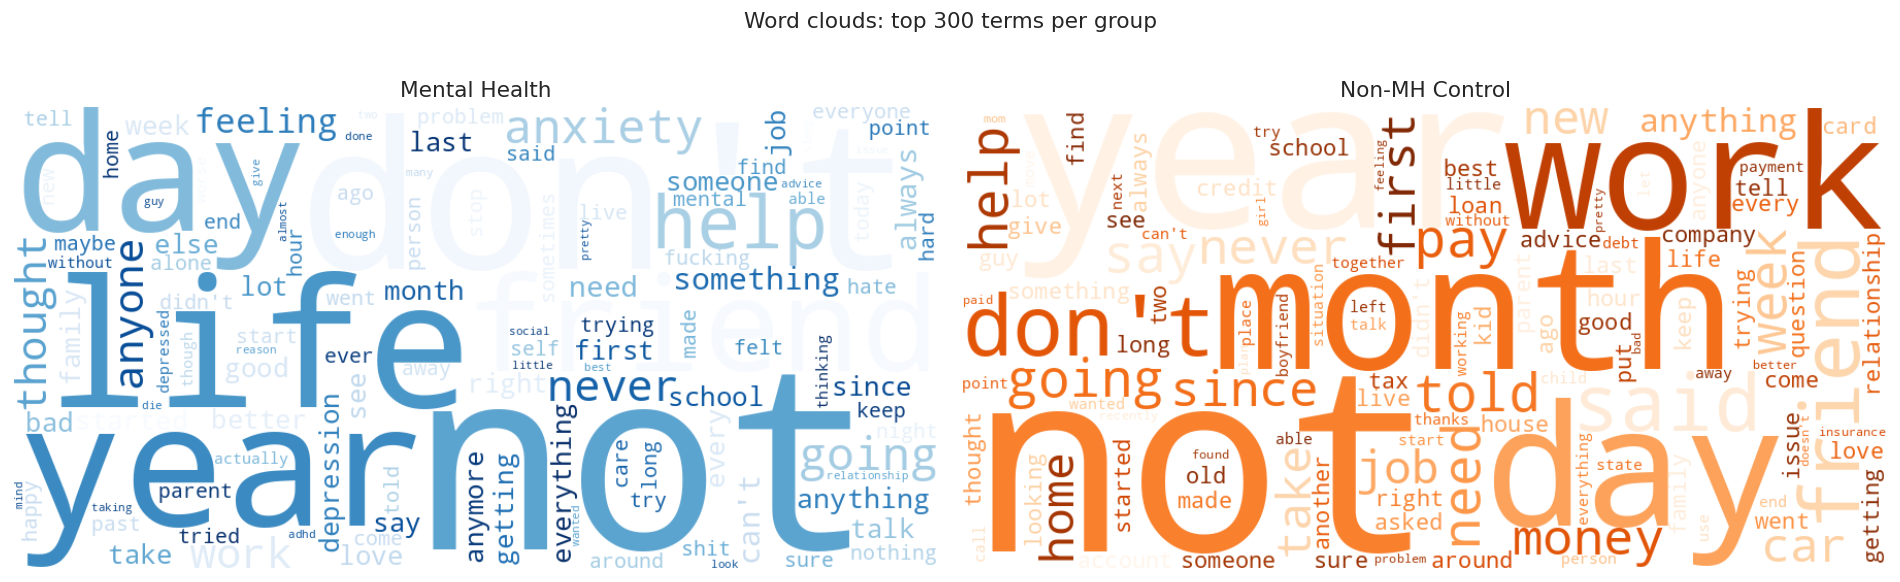

S3 artifacts saved.


In [25]:
# ── S3: Word clouds ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, counter, label, cmap in [
    (axes[0], mh_counter,    "Mental Health",  "Blues"),
    (axes[1], nonmh_counter, "Non-MH Control", "Oranges"),
]:
    wc = WordCloud(
        width=900, height=450, background_color="white",
        max_words=120, colormap=cmap, random_state=RANDOM_STATE,
        prefer_horizontal=0.8, min_font_size=8,
    ).generate_from_frequencies(dict(counter.most_common(300)))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(label, fontsize=13, fontweight="medium")

plt.suptitle("Word clouds: top 300 terms per group", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s3_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

# Export
freq_df = pd.concat([
    pd.DataFrame(mh_counter.most_common(150),    columns=["word","count"]).assign(group="mental_health"),
    pd.DataFrame(nonmh_counter.most_common(150), columns=["word","count"]).assign(group="non_mh"),
])
freq_df.to_csv(ARTIFACT_DIR / "s3_word_freq_by_group.csv", index=False)
print("S3 artifacts saved.")


## S4 — TF-IDF Distinctive Terms

Leverages the 256 pre-computed `tfidf_*` columns already in the dataset. Pure numeric aggregation — no text scan. Identifies which terms most discriminate MH from Non-MH, and which terms rose or fell post-COVID.

In [26]:
# ── S4: Discriminative score (MH mean − Non-MH mean) ─────────────────────────
tfidf_available = [c for c in TFIDF_COLS if c in df.columns]
terms = [c.replace("tfidf_", "") for c in tfidf_available]

tfidf_group_mean = df.groupby("is_mental_health")[tfidf_available].mean()

diff = tfidf_group_mean.loc[1].values - tfidf_group_mean.loc[0].values
disc_df = pd.DataFrame({
    "term":         terms,
    "mh_mean":      tfidf_group_mean.loc[1].values,
    "nonmh_mean":   tfidf_group_mean.loc[0].values,
    "diff":         diff,
}).assign(abs_diff=lambda x: x["diff"].abs()).sort_values("diff", ascending=False)

top_mh    = disc_df.head(20)
top_nonmh = disc_df.tail(20).sort_values("diff")


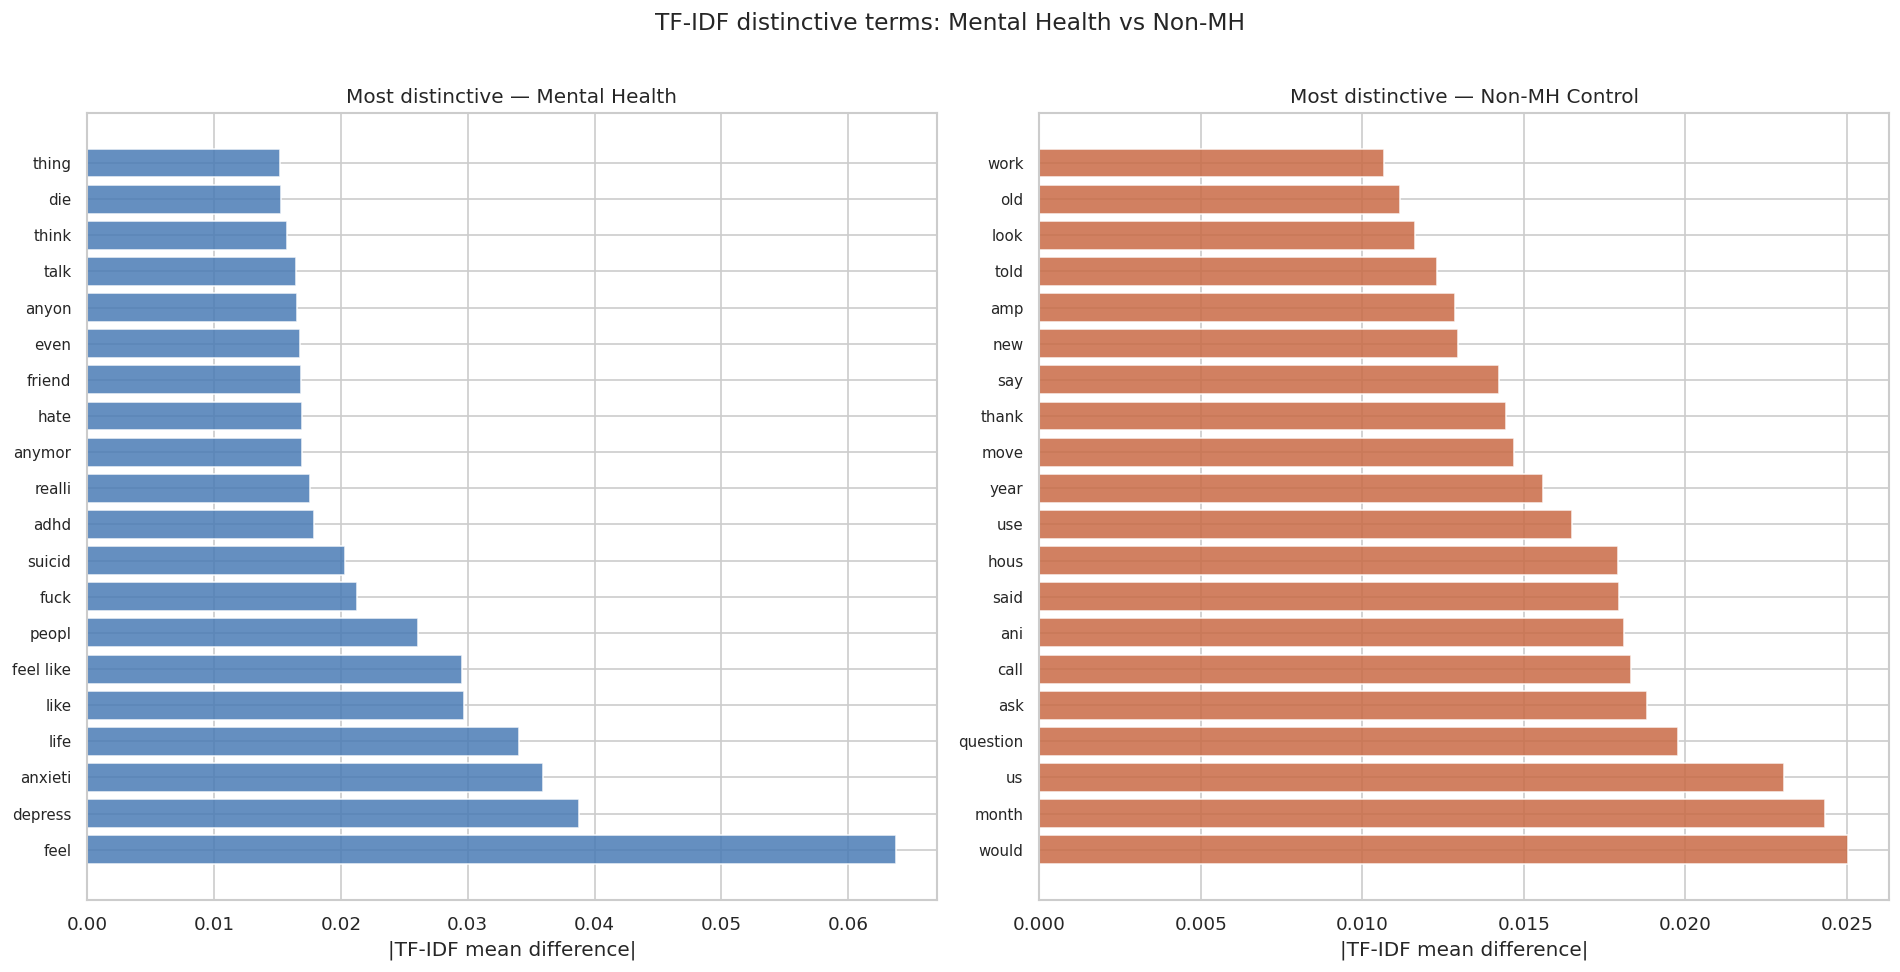

In [27]:
# ── S4: Distinctive terms bar chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, frame, label, color in [
    (axes[0], top_mh,    "Most distinctive — Mental Health",  "#4A7BB5"),
    (axes[1], top_nonmh, "Most distinctive — Non-MH Control", "#C96A45"),
]:
    ax.barh(frame["term"], frame["diff"].abs(), color=color, alpha=0.85)
    ax.set_title(label, fontsize=12, fontweight="medium")
    ax.set_xlabel("|TF-IDF mean difference|")
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("TF-IDF distinctive terms: Mental Health vs Non-MH", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s4_tfidf_distinctive.png", dpi=150, bbox_inches="tight")
plt.show()


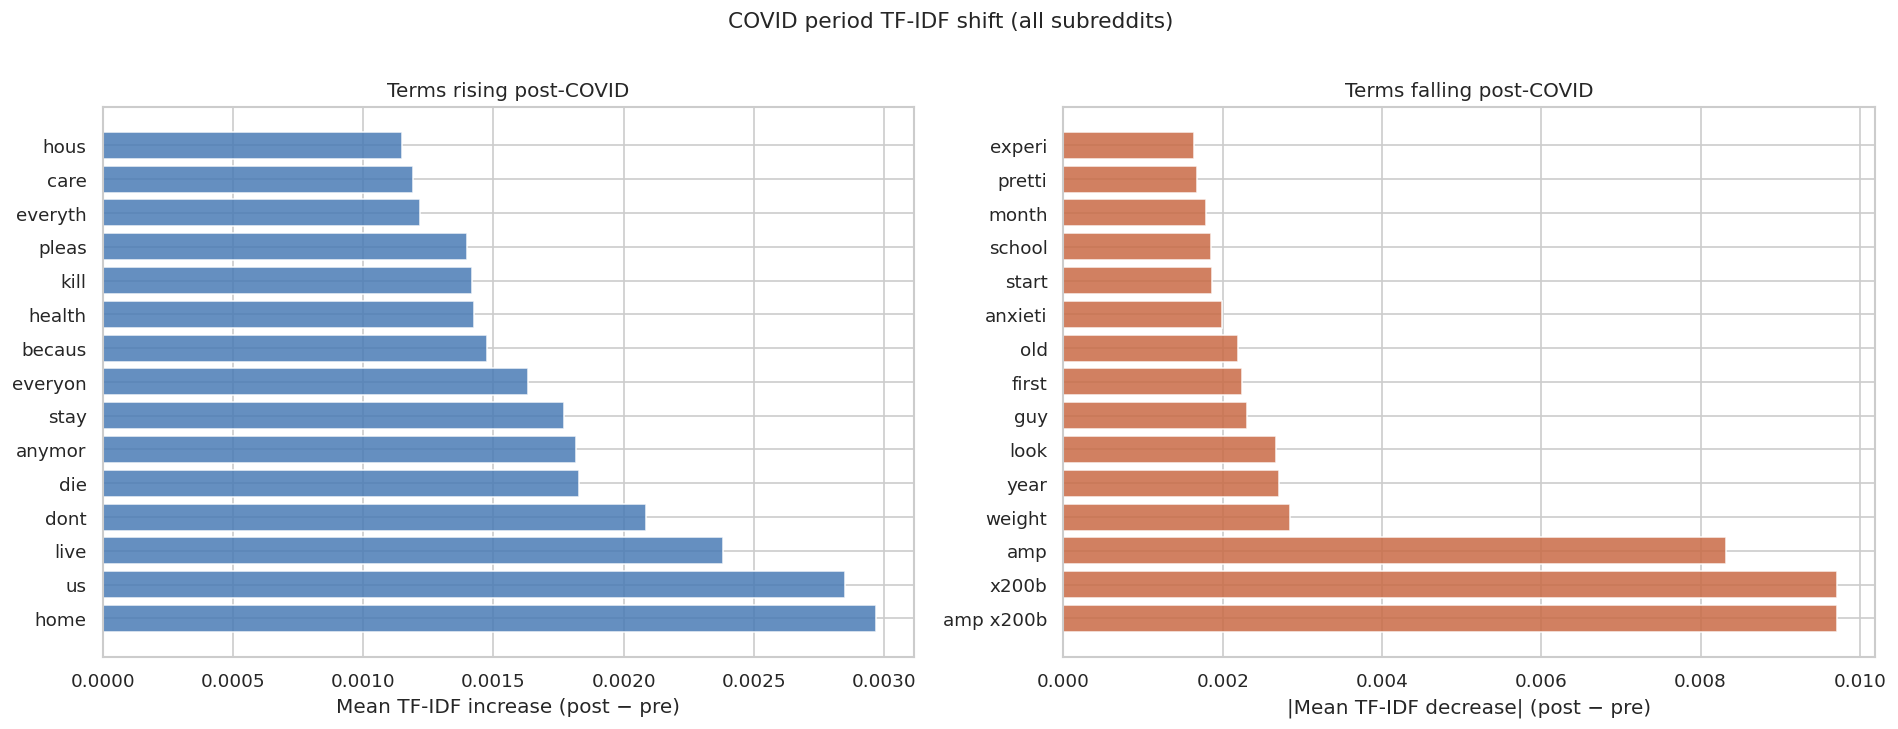

S4 artifacts saved.


In [28]:
# ── S4: Pre vs Post COVID TF-IDF shift ───────────────────────────────────────
tfidf_period = df.groupby("covid_period")[tfidf_available].mean()

if 0 in tfidf_period.index and 1 in tfidf_period.index:
    period_diff_vals = tfidf_period.loc[1].values - tfidf_period.loc[0].values
    period_df = pd.DataFrame({"term": terms, "post_minus_pre": period_diff_vals})
    top_rising  = period_df.nlargest(15,  "post_minus_pre")
    top_falling = period_df.nsmallest(15, "post_minus_pre")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].barh(top_rising["term"], top_rising["post_minus_pre"], color="#4A7BB5", alpha=0.85)
    axes[0].set_title("Terms rising post-COVID", fontsize=12)
    axes[0].set_xlabel("Mean TF-IDF increase (post − pre)")
    axes[1].barh(top_falling["term"], top_falling["post_minus_pre"].abs(), color="#C96A45", alpha=0.85)
    axes[1].set_title("Terms falling post-COVID", fontsize=12)
    axes[1].set_xlabel("|Mean TF-IDF decrease| (post − pre)")
    plt.suptitle("COVID period TF-IDF shift (all subreddits)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "s4_tfidf_covid_shift.png", dpi=150, bbox_inches="tight")
    plt.show()

disc_df.to_csv(ARTIFACT_DIR / "s4_tfidf_distinctive_terms.csv", index=False)
print("S4 artifacts saved.")


## S5 — N-gram Analysis

Uses the 50k stratified sample (`df_sample`). Extracts bigrams and trigrams per group; builds a co-occurrence network from top MH bigram pairs using NetworkX.

In [29]:
# ── S5: Top-N n-gram extractor ────────────────────────────────────────────────
def get_top_ngrams(texts: pd.Series, ngram_range=(2, 2), top_n: int = 25):
    """Fit CountVectorizer on texts and return sorted (phrase, count) list."""
    # Handle empty input Series to prevent ValueError from CountVectorizer
    if texts.empty or texts.dropna().empty:
        return []

    vec = CountVectorizer(
        ngram_range=ngram_range, max_features=8000,
        min_df=3, stop_words="english",
    )
    X = vec.fit_transform(texts.dropna())

    # If no vocabulary is formed after fit_transform (e.g., all words are stop words or min_df not met)
    if not vec.vocabulary_:
        return []

    counts = np.asarray(X.sum(axis=0)).flatten()
    terms  = vec.get_feature_names_out()

    # Ensure top_n does not exceed the number of available terms
    actual_top_n = min(top_n, len(terms))
    if actual_top_n == 0:
        return []

    top_idx = counts.argsort()[-actual_top_n:][::-1]
    return [(terms[i], int(counts[i])) for i in top_idx]

mh_sample_texts    = df_sample.loc[df_sample["is_mental_health"] == 1, "clean_text"]
nonmh_sample_texts = df_sample.loc[df_sample["is_mental_health"] == 0, "clean_text"]

mh_bi    = get_top_ngrams(mh_sample_texts,    (2, 2), 25)
nonmh_bi = get_top_ngrams(nonmh_sample_texts, (2, 2), 25)
mh_tri   = get_top_ngrams(mh_sample_texts,    (3, 3), 20)
nonmh_tri= get_top_ngrams(nonmh_sample_texts, (3, 3), 20)
print("N-grams extracted.")


N-grams extracted.


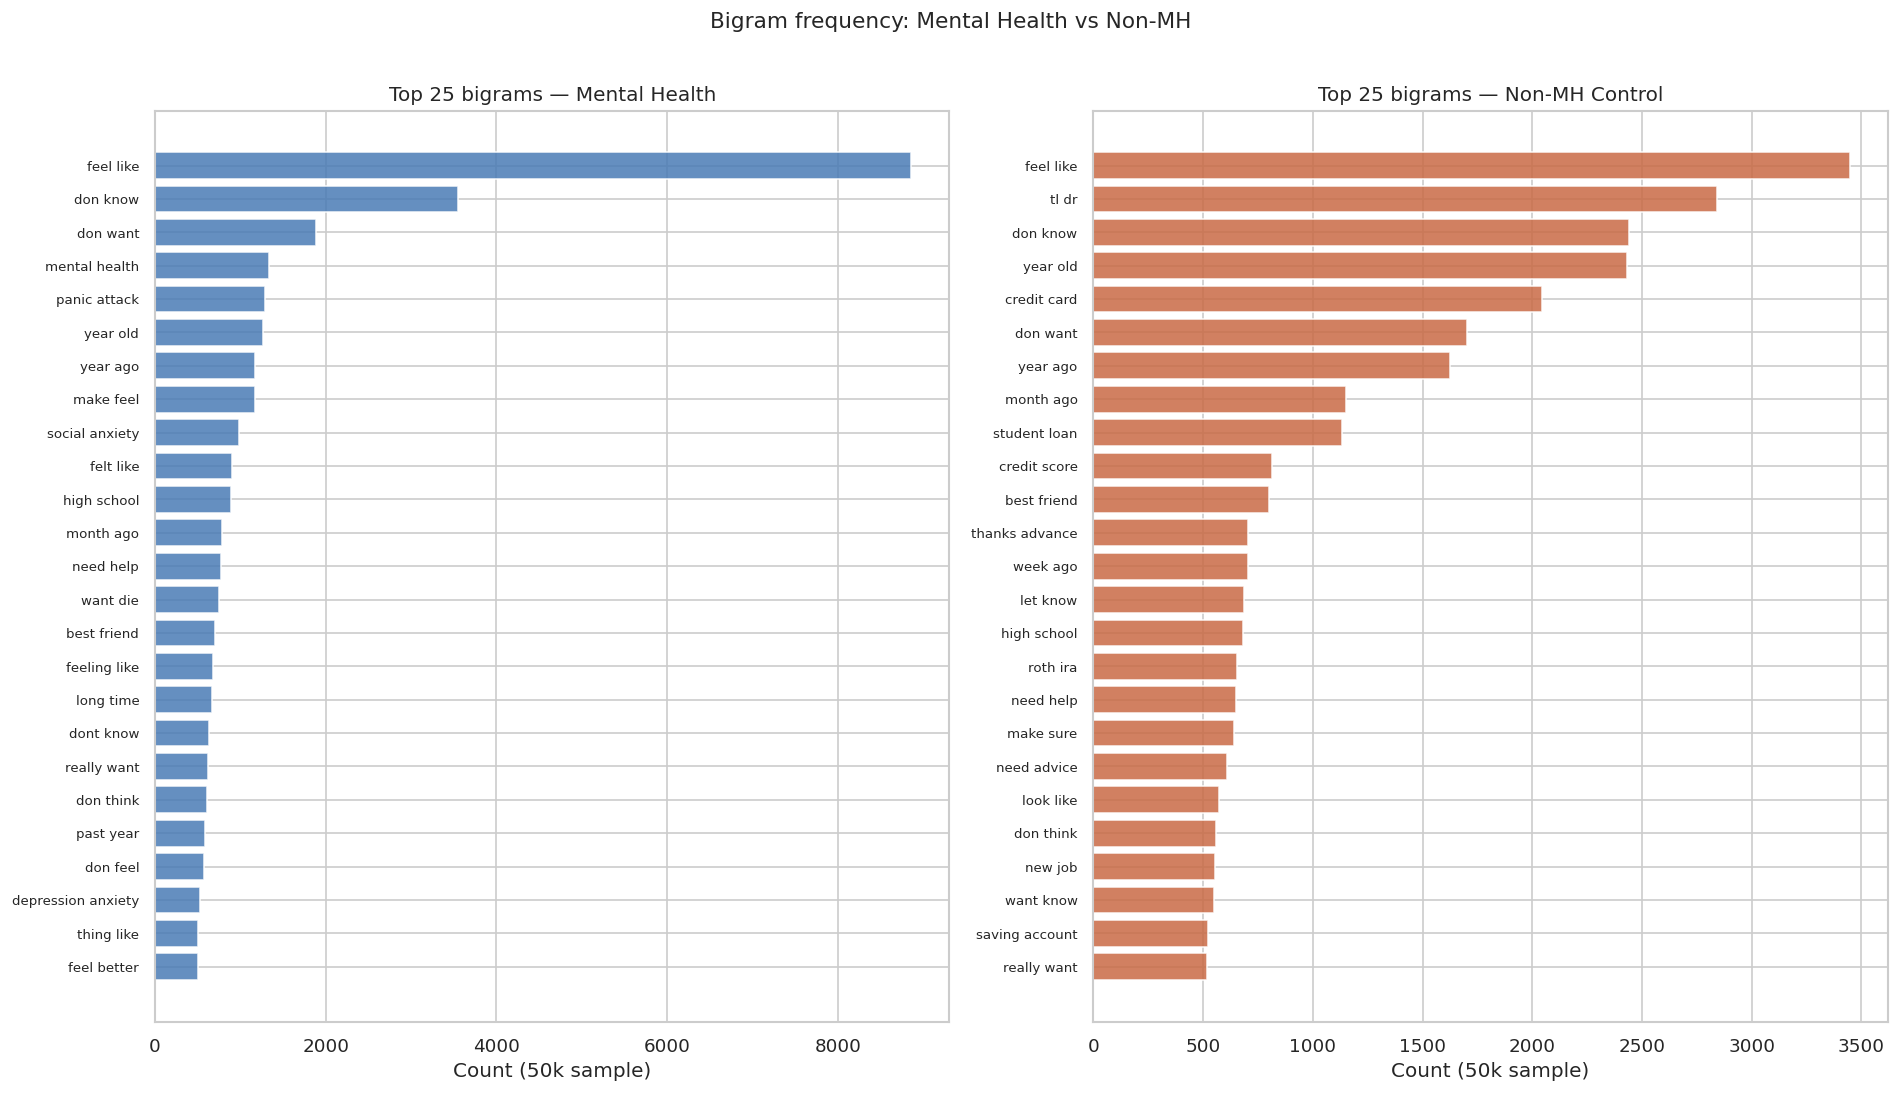

In [30]:
# ── S5: Bigram bar charts ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 9), sharey=False)

for ax, data, label, color in [
    (axes[0], mh_bi,    "Mental Health",  "#4A7BB5"),
    (axes[1], nonmh_bi, "Non-MH Control", "#C96A45"),
]:
    words, counts = zip(*data)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.85)
    ax.set_title(f"Top 25 bigrams — {label}", fontsize=12, fontweight="medium")
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel("Count (50k sample)")

plt.suptitle("Bigram frequency: Mental Health vs Non-MH", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s5_bigrams.png", dpi=150, bbox_inches="tight")
plt.show()


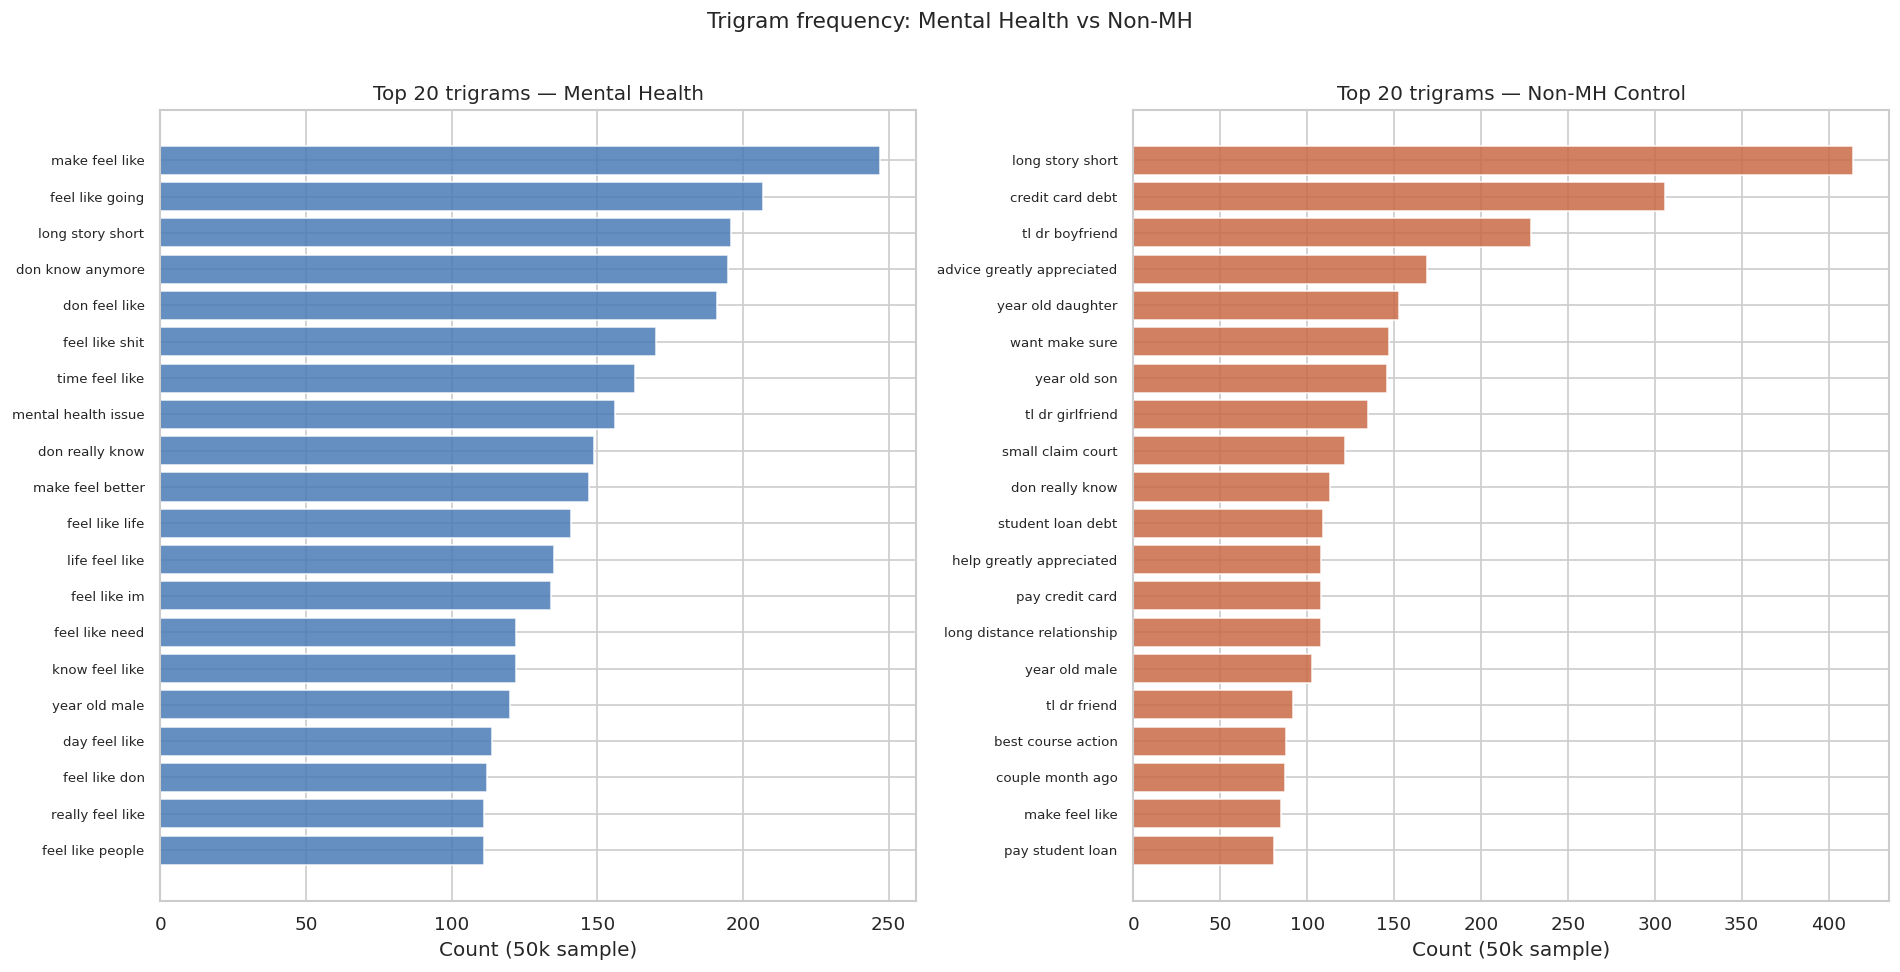

In [31]:
# ── S5: Trigram bar charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

for ax, data, label, color in [
    (axes[0], mh_tri,    "Mental Health",  "#4A7BB5"),
    (axes[1], nonmh_tri, "Non-MH Control", "#C96A45"),
]:
    words, counts = zip(*data)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.85)
    ax.set_title(f"Top 20 trigrams — {label}", fontsize=12, fontweight="medium")
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel("Count (50k sample)")

plt.suptitle("Trigram frequency: Mental Health vs Non-MH", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s5_trigrams.png", dpi=150, bbox_inches="tight")
plt.show()


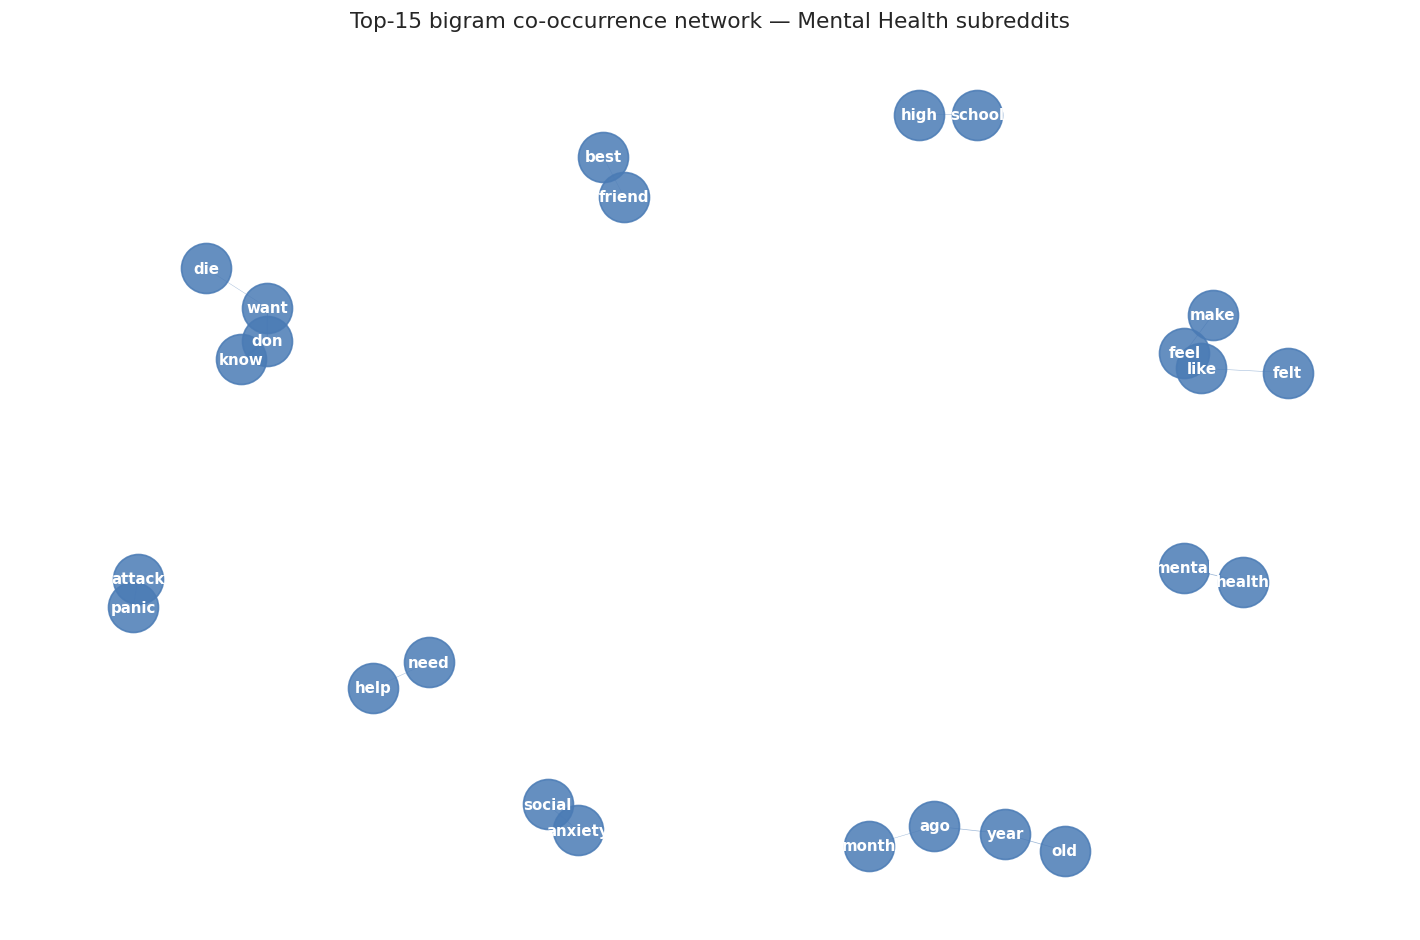

S5 artifacts saved.


In [32]:
# ── S5: Co-occurrence network (top 15 MH bigrams) ───────────────────────────
G = nx.Graph()
for phrase, count in mh_bi[:15]:
    parts = phrase.split(" ", 1)
    if len(parts) == 2:
        G.add_edge(parts[0], parts[1], weight=count)

pos = nx.spring_layout(G, seed=RANDOM_STATE, k=2.2)
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
max_w = max(edge_weights) if edge_weights else 1

fig, ax = plt.subplots(figsize=(12, 8))
nx.draw_networkx_edges(G, pos, ax=ax,
    width=[3 * w / max_w for w in edge_weights], alpha=0.55, edge_color="#4A7BB5")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=900, node_color="#4A7BB5", alpha=0.85)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color="white", font_weight="bold")
ax.set_title("Top-15 bigram co-occurrence network — Mental Health subreddits", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s5_bigram_network_mh.png", dpi=150, bbox_inches="tight")
plt.show()

# Export
ngram_df = pd.concat([
    pd.DataFrame(mh_bi,    columns=["phrase","count"]).assign(n=2, group="mental_health"),
    pd.DataFrame(nonmh_bi, columns=["phrase","count"]).assign(n=2, group="non_mh"),
    pd.DataFrame(mh_tri,    columns=["phrase","count"]).assign(n=3, group="mental_health"),
    pd.DataFrame(nonmh_tri, columns=["phrase","count"]).assign(n=3, group="non_mh"),
])
ngram_df.to_csv(ARTIFACT_DIR / "s5_ngram_freq.csv", index=False)
print("S5 artifacts saved.")


## S10 — LDA Topic Modelling

Uses the 50k stratified sample. Gensim processes documents as a streaming iterator — the full token list is never held in RAM simultaneously. Coherence scan over 5–12 topics selects the best model. pyLDAvis replaced with a top-words bar grid.

In [47]:
# ── S10: Build Gensim dictionary and corpus (streaming) ──────────────────────
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

lda_df    = df_sample[df_sample["clean_text"].str.len() > 10].copy().reset_index(drop=True)
lda_texts = lda_df["clean_text"].str.split().tolist()

dictionary = corpora.Dictionary(lda_texts)
dictionary.filter_extremes(no_below=10, no_above=0.85, keep_n=8000)
corpus = [dictionary.doc2bow(text) for text in lda_texts]

print(f"Dictionary : {len(dictionary):,} tokens")
print(f"Corpus     : {len(corpus):,} documents")


Dictionary : 8,000 tokens
Corpus     : 49,986 documents


In [54]:
# ── S10: Optimized coherence scan over topic counts 5–12 ───────────────────
# Optimization: Reduced passes and increased chunksize for faster estimation
NUM_TOPICS_RANGE = range(5, 13)
coherence_scores = []

for n in NUM_TOPICS_RANGE:
    # Using fewer passes (1 instead of 5) for the scan phase to save time
    model_tmp = LdaModel(
        corpus=corpus,
        num_topics=n,
        id2word=dictionary,
        passes=1,
        alpha="auto",
        eta="auto",
        random_state=RANDOM_STATE,
        chunksize=5000, # Increased chunksize for speed
    )
    cm = CoherenceModel(model=model_tmp, texts=lda_texts,
                         dictionary=dictionary, coherence="c_v")
    coh = cm.get_coherence()
    coherence_scores.append((n, coh))
    print(f"  topics={n:2d}  coherence={coh:.4f}")

best_n, best_coh = max(coherence_scores, key=lambda x: x[1])
print(f"\nBest: {best_n} topics (coherence={best_coh:.4f})")

  topics= 5  coherence=0.3198


  topics= 6  coherence=0.3706


  topics= 7  coherence=0.3494


  topics= 8  coherence=0.3452


  topics= 9  coherence=0.3496


  topics=10  coherence=0.3803


  topics=11  coherence=0.3691
  topics=12  coherence=0.3691

Best: 10 topics (coherence=0.3803)


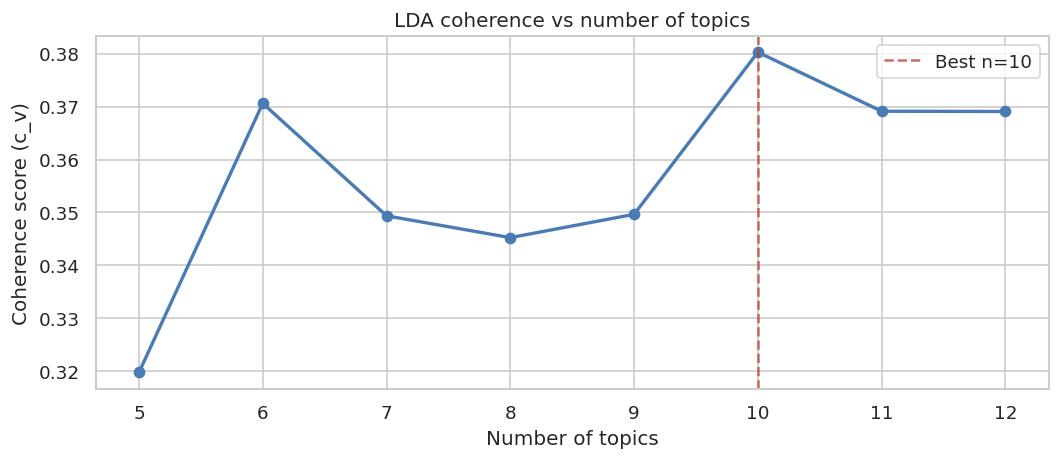

In [55]:
# ── S10: Coherence curve ─────────────────────────────────────────────────────
coh_df = pd.DataFrame(coherence_scores, columns=["num_topics", "coherence"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(coh_df["num_topics"], coh_df["coherence"], marker="o", color="#4A7BB5", linewidth=2)
ax.axvline(best_n, color="#B84030", linestyle="--", alpha=0.75, label=f"Best n={best_n}")
ax.set_xlabel("Number of topics")
ax.set_ylabel("Coherence score (c_v)")
ax.set_title("LDA coherence vs number of topics", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s10_coherence_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [56]:
# ── S10: Fit final model ──────────────────────────────────────────────────────
final_lda = LdaModel(
    corpus=corpus, num_topics=best_n, id2word=dictionary,
    passes=12, alpha="auto", eta="auto",
    random_state=RANDOM_STATE, chunksize=2000,
)
print(f"Final LDA fitted: {best_n} topics, 12 passes")


Final LDA fitted: 10 topics, 12 passes


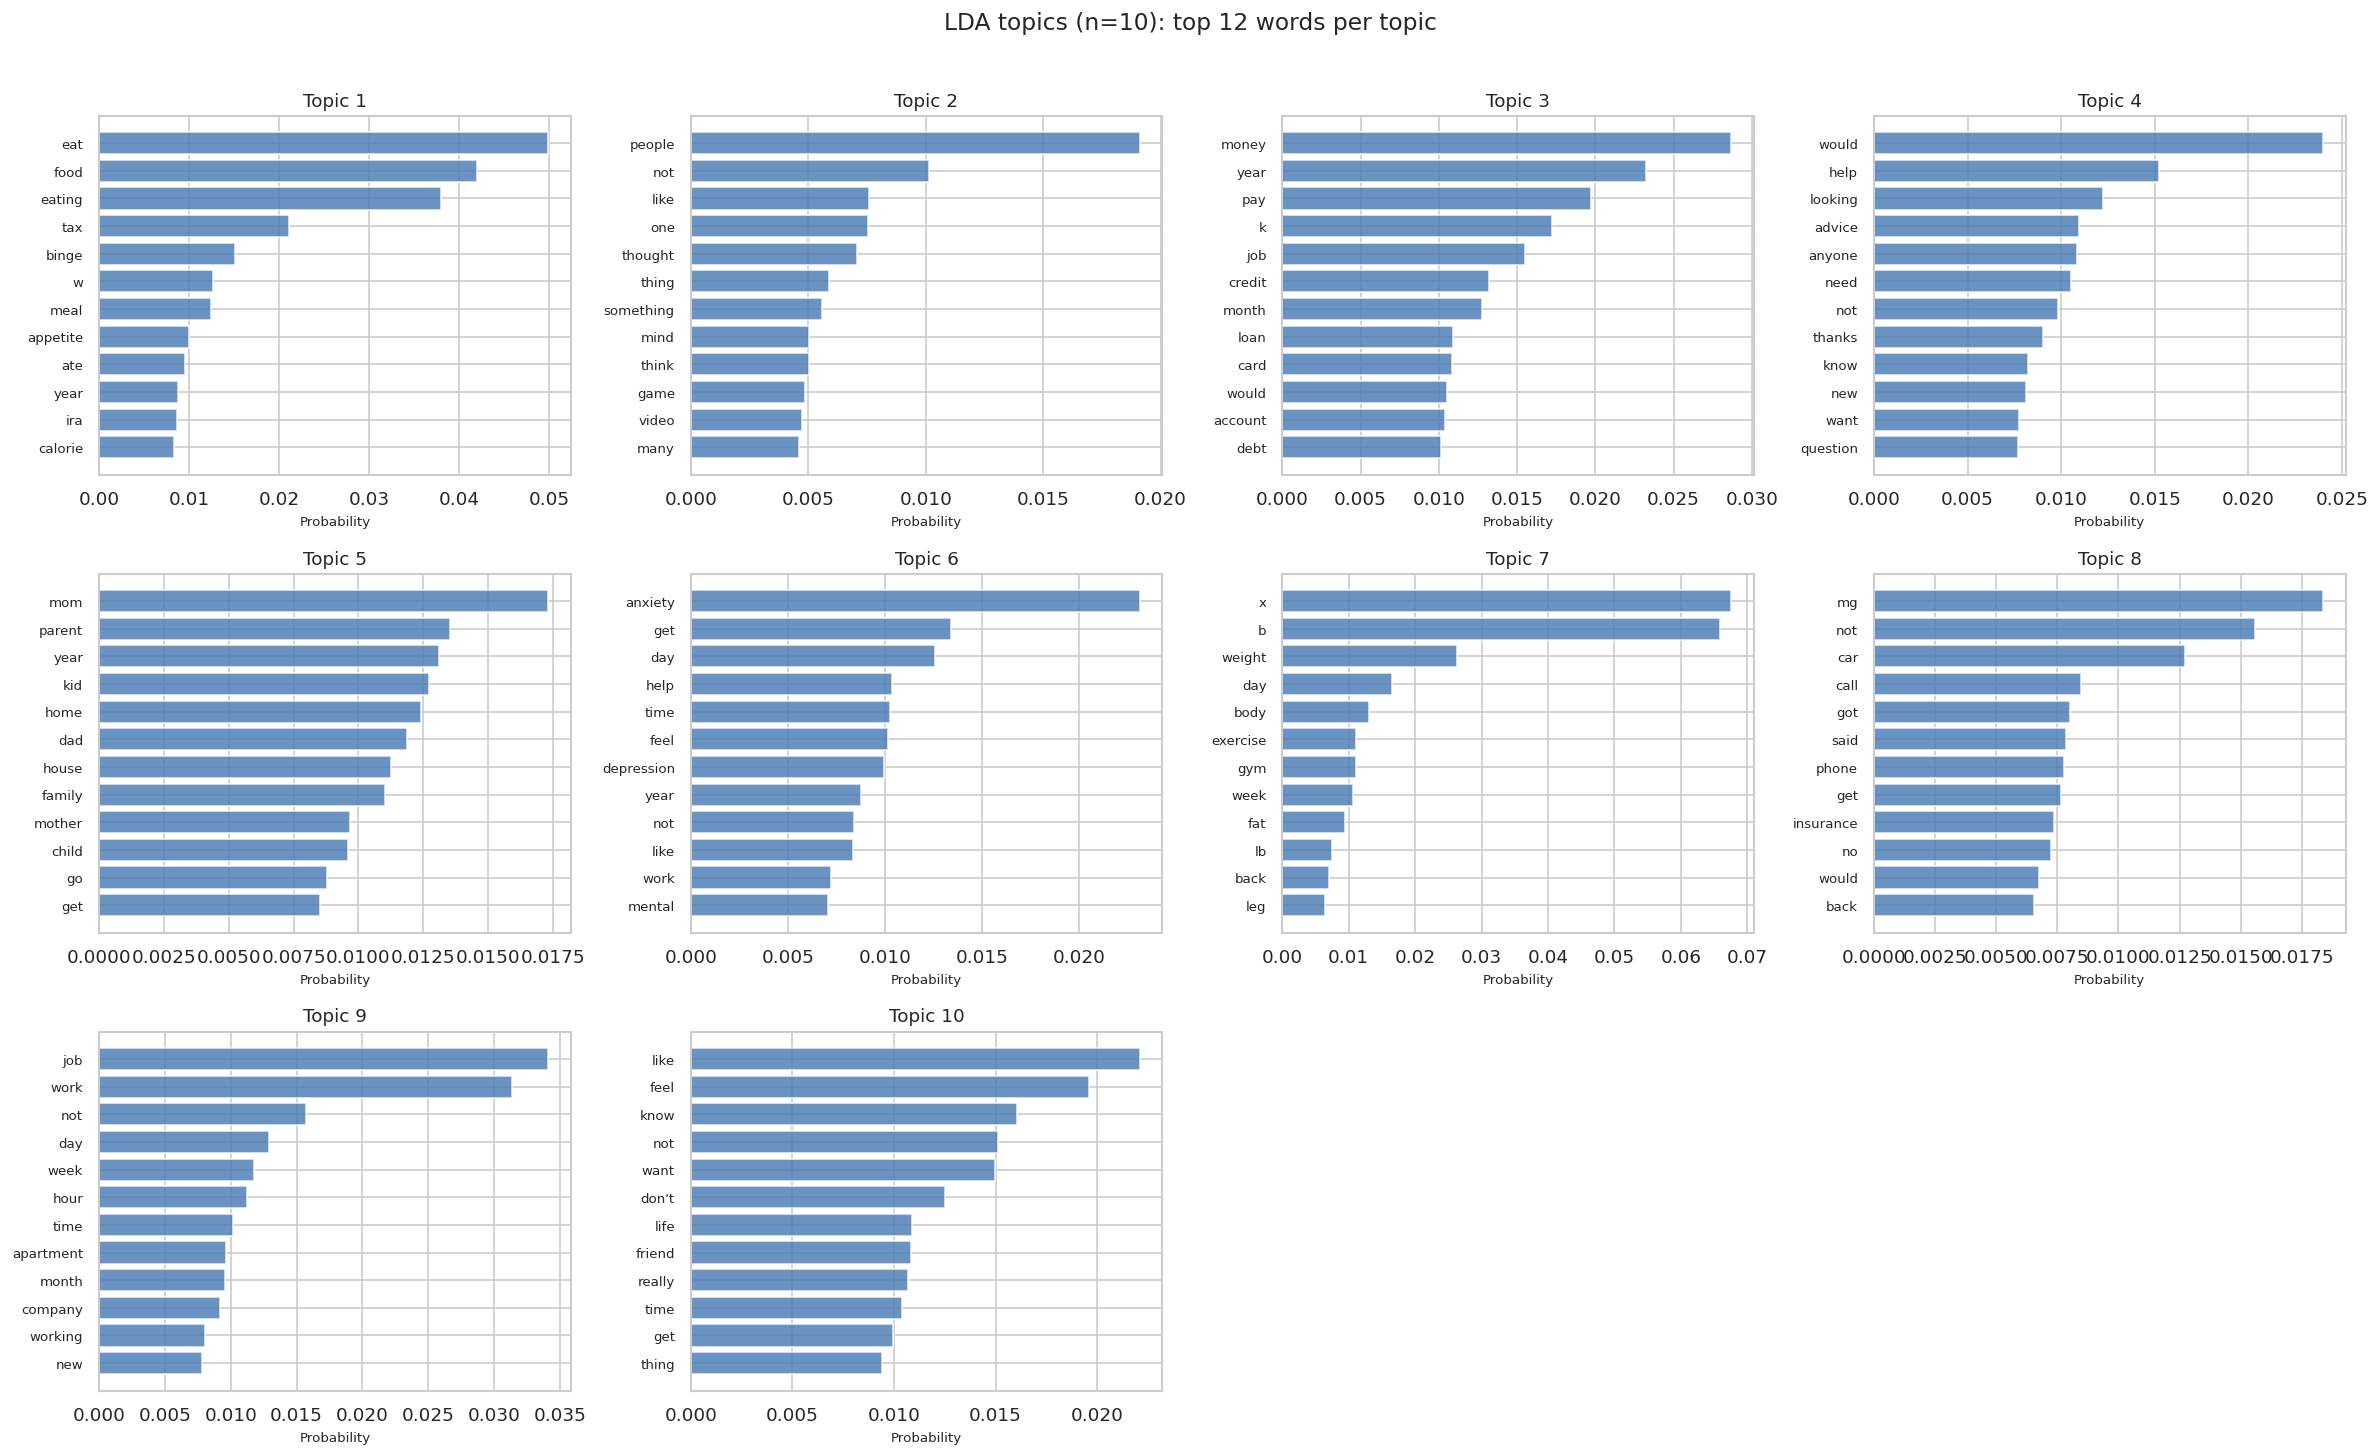

In [57]:
# ── S10: Top-words bar grid (replaces pyLDAvis) ───────────────────────────────
TOP_WORDS = 12
n_cols = 4
n_rows = math.ceil(best_n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for t in range(best_n):
    top_words  = final_lda.show_topic(t, topn=TOP_WORDS)
    words, probs = zip(*top_words)
    ax = axes[t]
    ax.barh(list(words)[::-1], list(probs)[::-1], color="#4A7BB5", alpha=0.82)
    ax.set_title(f"Topic {t + 1}", fontsize=11, fontweight="medium")
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel("Probability", fontsize=8)

for j in range(best_n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"LDA topics (n={best_n}): top {TOP_WORDS} words per topic", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s10_lda_top_words_grid.png", dpi=150, bbox_inches="tight")
plt.show()


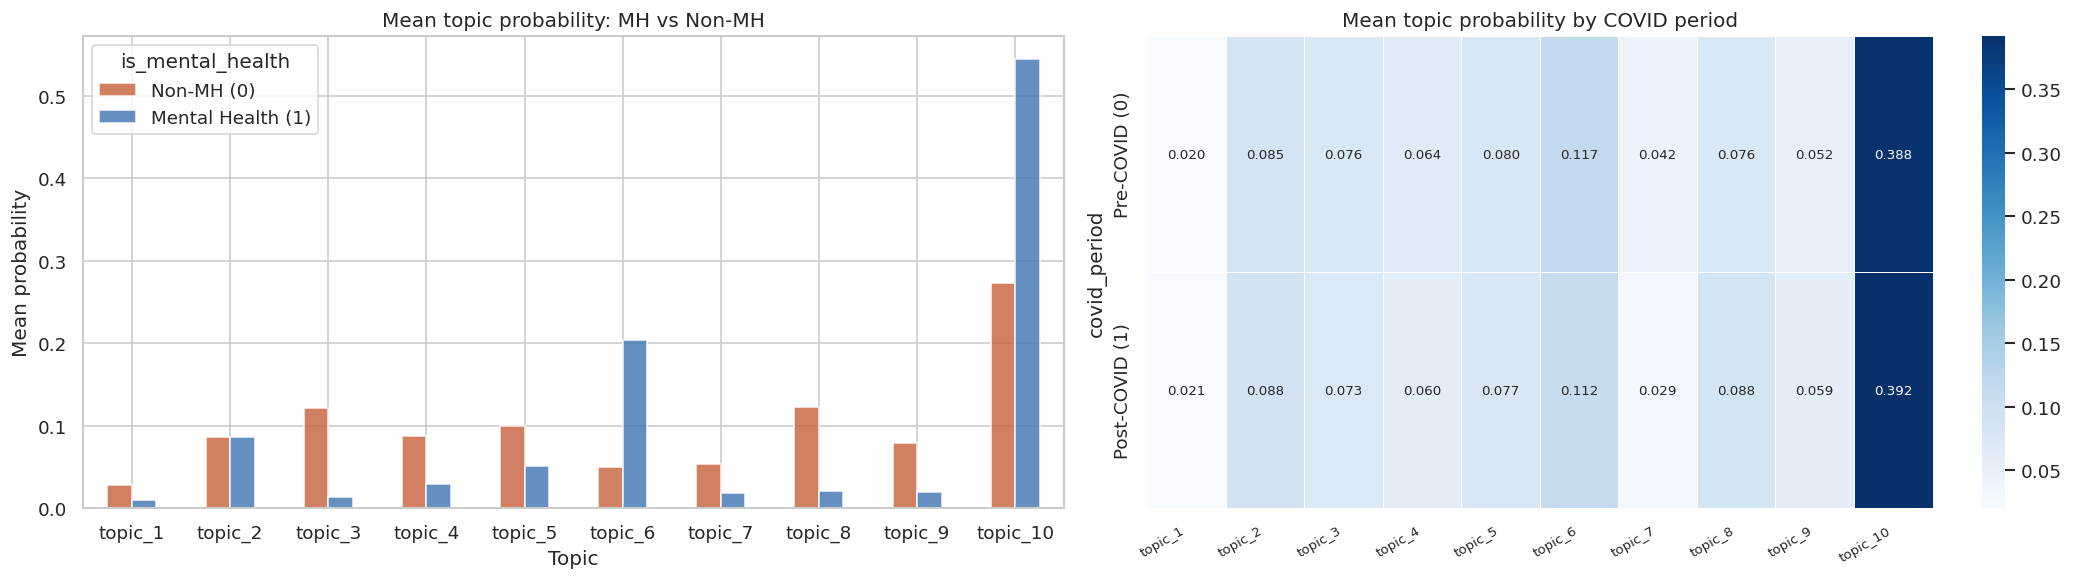

S10 artifacts saved.


In [58]:
# ── S10: Topic distribution per group and COVID period ────────────────────────
topic_probs = []
for bow in corpus:
    row = dict(final_lda.get_document_topics(bow, minimum_probability=0))
    topic_probs.append(row)

topic_prob_df = pd.DataFrame(topic_probs).fillna(0)
topic_prob_df.columns = [f"topic_{int(c) + 1}" for c in topic_prob_df.columns]
topic_prob_df["is_mental_health"] = lda_df["is_mental_health"].values
topic_prob_df["covid_period"]     = lda_df["covid_period"].values
topic_prob_df["subreddit"]        = lda_df["subreddit"].values

topic_cols  = [c for c in topic_prob_df.columns if c.startswith("topic_")]
topic_group = topic_prob_df.groupby("is_mental_health")[topic_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Bar chart by group
ax = axes[0]
topic_group.T.plot(kind="bar", ax=ax, color=["#C96A45", "#4A7BB5"], alpha=0.85)
ax.set_title("Mean topic probability: MH vs Non-MH", fontsize=12)
ax.set_xlabel("Topic")
ax.set_ylabel("Mean probability")
ax.legend(["Non-MH (0)", "Mental Health (1)"], title="is_mental_health")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Heatmap by COVID period
ax = axes[1]
topic_period = topic_prob_df.groupby("covid_period")[topic_cols].mean()
sns.heatmap(topic_period, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=topic_cols, yticklabels=["Pre-COVID (0)", "Post-COVID (1)"],
            linewidths=0.4, ax=ax, annot_kws={"size": 8})
ax.set_title("Mean topic probability by COVID period", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s10_topic_group_period.png", dpi=150, bbox_inches="tight")
plt.show()

# Export
topic_word_rows = [
    {"topic": t + 1, "rank": r + 1, "word": w, "probability": round(p, 6)}
    for t in range(best_n)
    for r, (w, p) in enumerate(final_lda.show_topic(t, topn=15))
]
pd.DataFrame(topic_word_rows).to_csv(ARTIFACT_DIR / "s10_lda_topic_words.csv", index=False)
topic_prob_df.to_csv(ARTIFACT_DIR / "s10_lda_topic_dist.csv", index=False)
print("S10 artifacts saved.")


## S11 — Cosine Similarity Between Subreddits

Aggregates the 256 pre-computed TF-IDF columns to a per-subreddit mean vector (28 rows × 256 cols — tiny). Computes pairwise cosine similarity and a pre vs post COVID delta to detect linguistic convergence during the pandemic.

In [59]:
# ── S11: Build subreddit-level TF-IDF vectors ─────────────────────────────────
tfidf_available = [c for c in TFIDF_COLS if c in df.columns]
tfidf_by_sub    = df.groupby("subreddit")[tfidf_available].mean()
subreddits      = tfidf_by_sub.index.tolist()

cos_sim = cosine_similarity(tfidf_by_sub.values)
cos_df  = pd.DataFrame(cos_sim, index=subreddits, columns=subreddits)

print(f"Similarity matrix: {cos_df.shape[0]} × {cos_df.shape[1]} subreddits")
most_similar = cos_df.stack().replace(1.0, 0).idxmax()
print(f"Most similar pair: {most_similar}  (score={cos_df.loc[most_similar]:.4f})")


Similarity matrix: 28 × 28 subreddits
Most similar pair: ('suicidewatch', 'suicidewatch')  (score=1.0000)


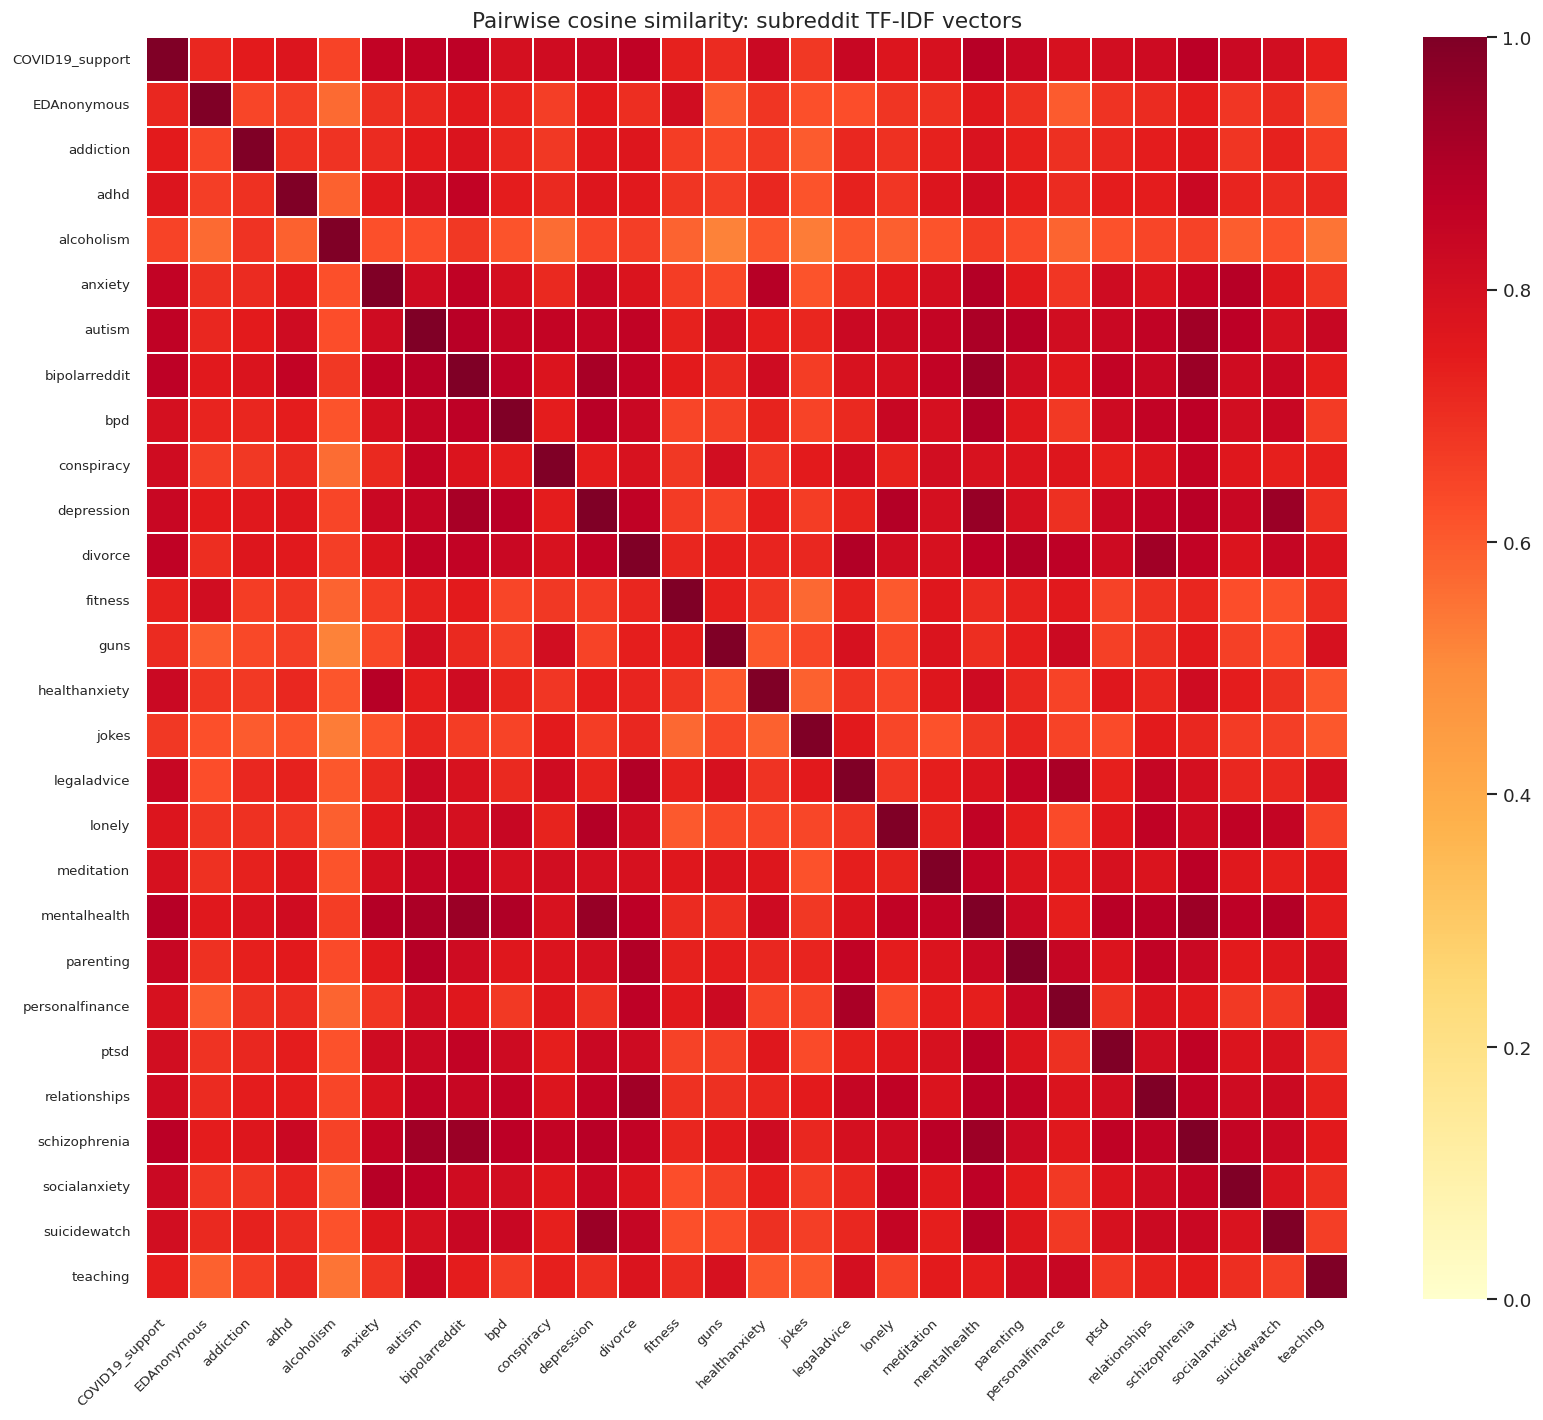

In [60]:
# ── S11: Full cosine heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cos_df, cmap="YlOrRd", linewidths=0.2, ax=ax,
            xticklabels=subreddits, yticklabels=subreddits,
            vmin=0, vmax=1)
ax.set_title("Pairwise cosine similarity: subreddit TF-IDF vectors", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s11_cosine_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


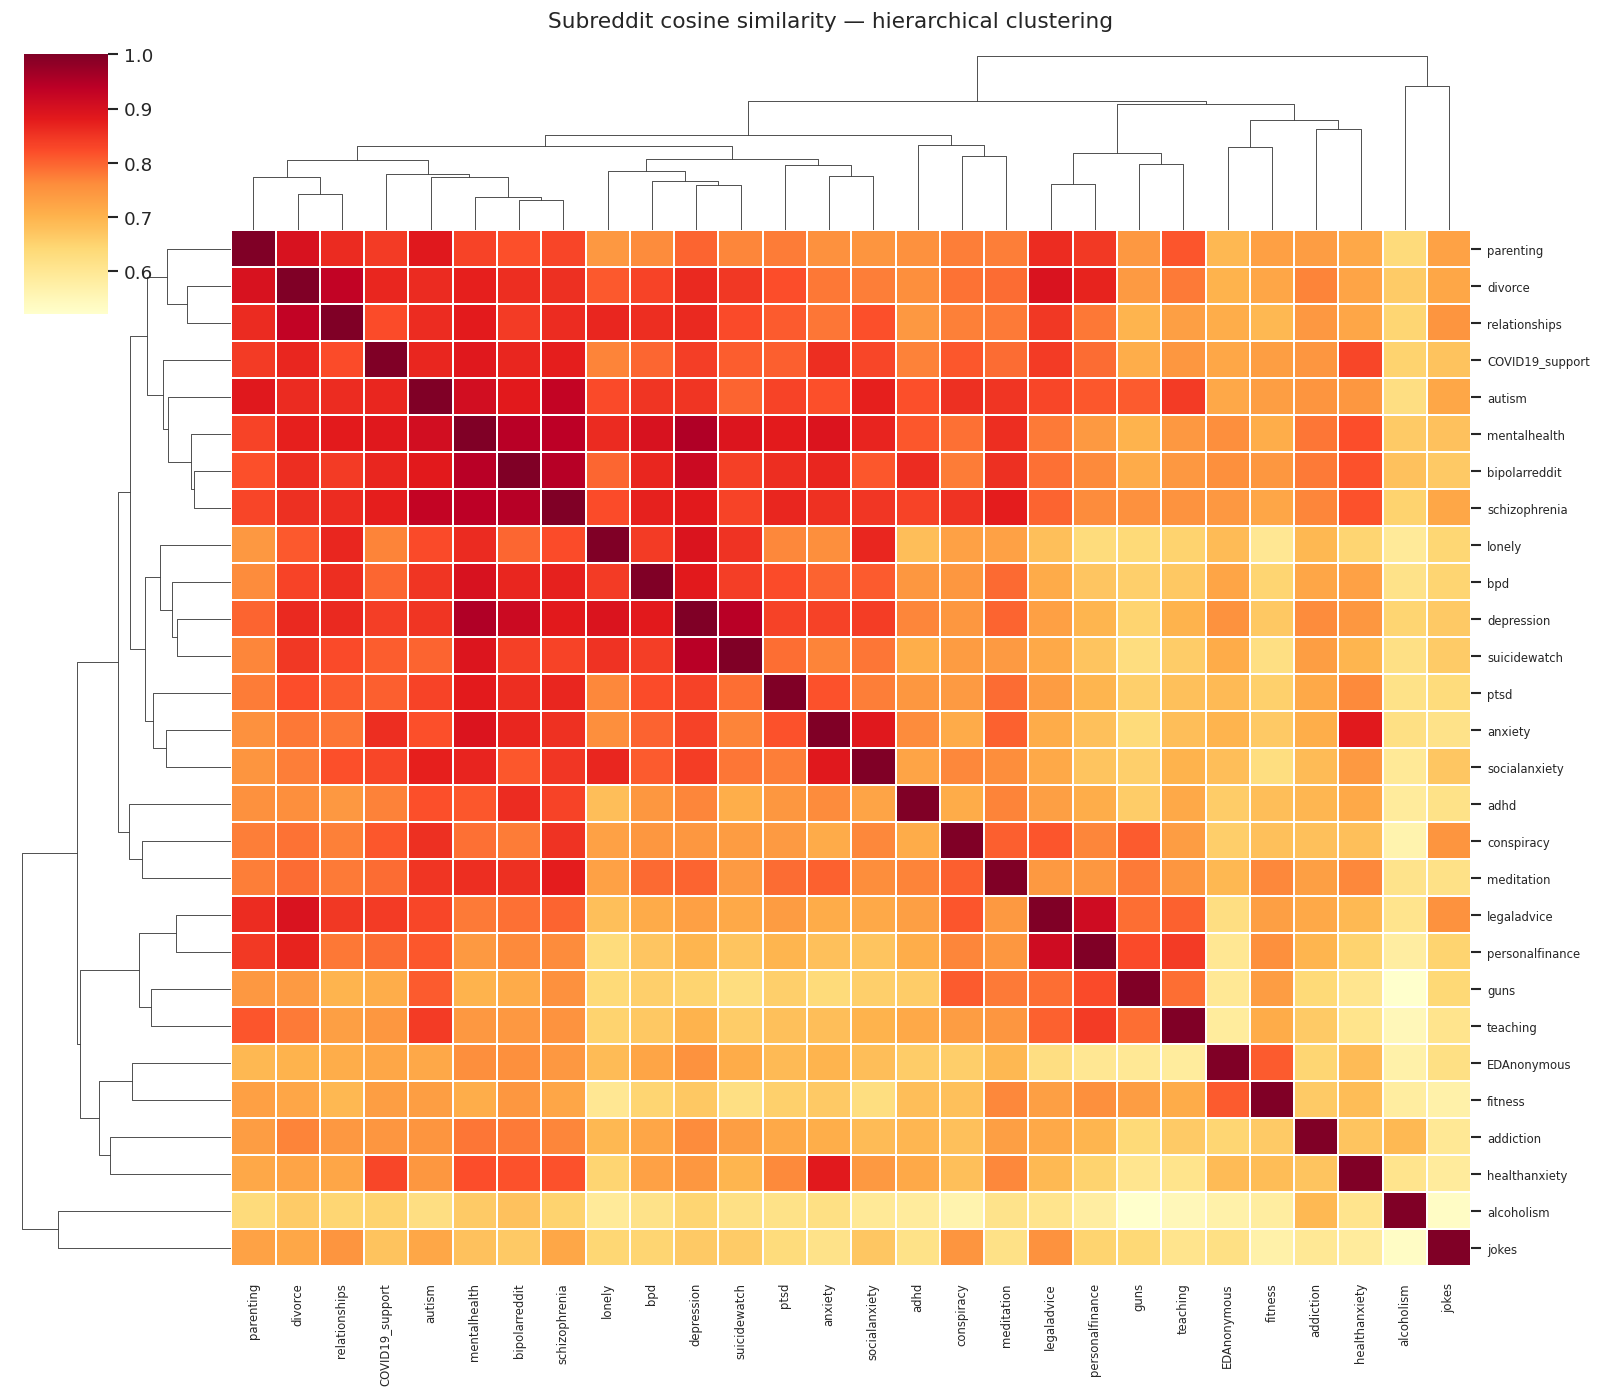

In [61]:
# ── S11: Clustermap (dendrogrammed) ──────────────────────────────────────────
clust = sns.clustermap(cos_df, cmap="YlOrRd", figsize=(14, 12),
                       xticklabels=True, yticklabels=True,
                       dendrogram_ratio=0.15, linewidths=0.2)
clust.ax_heatmap.set_xticklabels(clust.ax_heatmap.get_xticklabels(), fontsize=7)
clust.ax_heatmap.set_yticklabels(clust.ax_heatmap.get_yticklabels(), fontsize=7)
clust.figure.suptitle("Subreddit cosine similarity — hierarchical clustering", fontsize=13, y=1.01)
plt.savefig(ARTIFACT_DIR / "s11_cosine_clustermap.png", dpi=150, bbox_inches="tight")
plt.show()


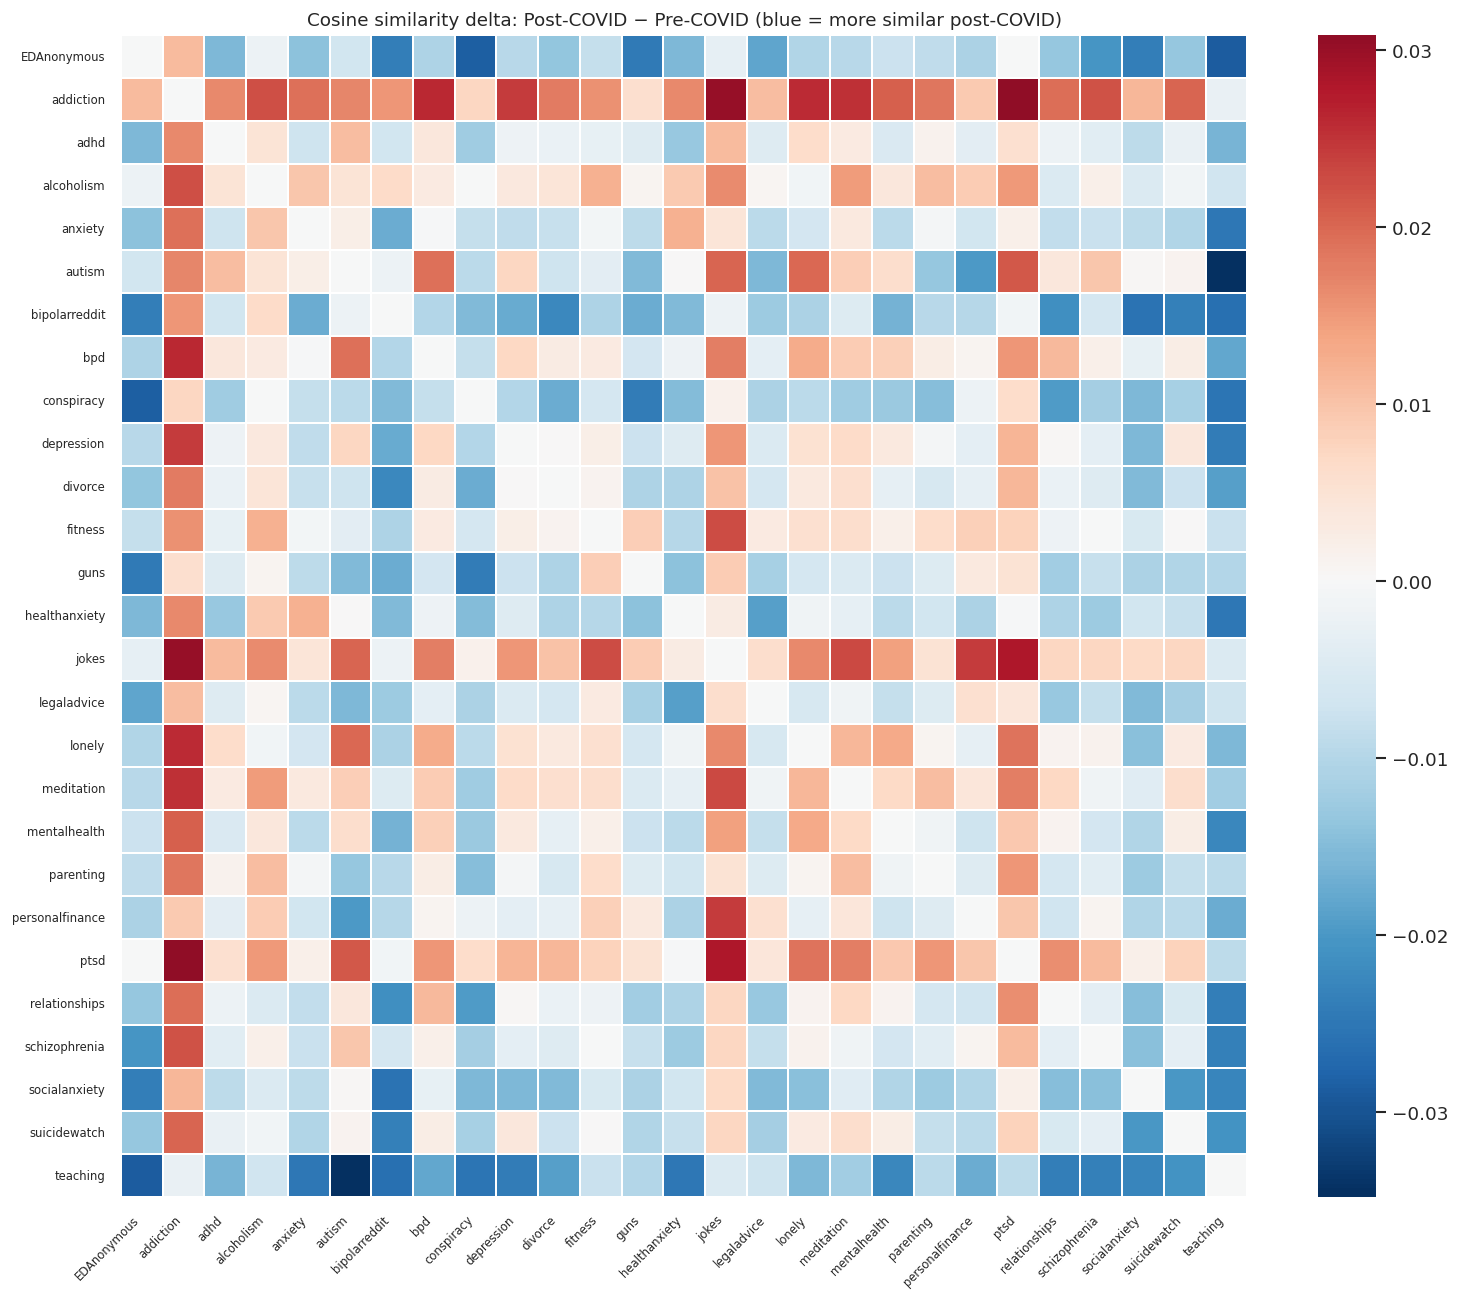

S11 artifacts saved.


In [62]:
# ── S11: Pre vs Post COVID cosine delta ──────────────────────────────────────
pre_vecs  = df[df["covid_period"] == 0].groupby("subreddit")[tfidf_available].mean()
post_vecs = df[df["covid_period"] == 1].groupby("subreddit")[tfidf_available].mean()
common_sub = pre_vecs.index.intersection(post_vecs.index).tolist()

pre_sim  = cosine_similarity(pre_vecs.loc[common_sub].values)
post_sim = cosine_similarity(post_vecs.loc[common_sub].values)
delta_df = pd.DataFrame(post_sim - pre_sim, index=common_sub, columns=common_sub)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(delta_df, cmap="RdBu_r", center=0, linewidths=0.2, ax=ax,
            xticklabels=common_sub, yticklabels=common_sub)
ax.set_title("Cosine similarity delta: Post-COVID − Pre-COVID (blue = more similar post-COVID)", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s11_cosine_delta.png", dpi=150, bbox_inches="tight")
plt.show()

cos_df.to_csv(ARTIFACT_DIR / "s11_cosine_similarity_matrix.csv")
delta_df.to_csv(ARTIFACT_DIR / "s11_cosine_delta_matrix.csv")
print("S11 artifacts saved.")


## S13 — Word Relationships & PMI Co-occurrence

Pointwise Mutual Information (PMI) identifies word pairs that co-occur more than expected by chance. Computed on the 50k sample. Network graphs surface thematic clusters within MH and Non-MH communities. Word2Vec is excluded to maintain runtime within Colab free-tier limits.

In [77]:
# ── S13: PMI calculation ──────────────────────────────────────────────────────
def compute_pmi_top(texts: pd.Series, vocab_size: int = 3000,
                    top_n: int = 35, min_freq: int = 5) -> pd.DataFrame:
    """
    Compute PMI for all bigrams in texts.
    Returns DataFrame sorted by PMI (highest first), filtered to min_freq.
    """
    clean = texts.dropna()
    n_docs = len(clean)

    uni_vec = CountVectorizer(max_features=vocab_size, min_df=min_freq, ngram_range=(1, 1))
    bi_vec  = CountVectorizer(max_features=vocab_size * 3, min_df=min_freq, ngram_range=(2, 2))

    X_uni = uni_vec.fit_transform(clean)
    X_bi  = bi_vec.fit_transform(clean)

    uni_freq = np.asarray(X_uni.sum(axis=0)).flatten() / n_docs
    bi_freq  = np.asarray(X_bi.sum(axis=0)).flatten() / n_docs
    bi_raw   = np.asarray(X_bi.sum(axis=0)).flatten()

    uni_vocab = uni_vec.vocabulary_

    rows = []
    for i, bigram in enumerate(bi_vec.get_feature_names_out()):
        parts = bigram.split(" ", 1)
        if len(parts) != 2:
            continue
        w1, w2 = parts
        if w1 not in uni_vocab or w2 not in uni_vocab:
            continue
        p_xy = bi_freq[i]
        p_x  = uni_freq[uni_vocab[w1]]
        p_y  = uni_freq[uni_vocab[w2]]
        if p_xy > 0 and p_x > 0 and p_y > 0:
            pmi = math.log2(p_xy / (p_x * p_y))
            rows.append({"bigram": bigram, "w1": w1, "w2": w2,
                          "pmi": round(pmi, 4), "freq": int(bi_raw[i])})

    df_pmi = pd.DataFrame(rows)
    return df_pmi[df_pmi["freq"] >= min_freq].sort_values("pmi", ascending=False).head(top_n)

mh_texts_s    = df_sample.loc[df_sample["is_mental_health"] == 1, "clean_text"]
nonmh_texts_s = df_sample.loc[df_sample["is_mental_health"] == 0, "clean_text"]

mh_pmi    = compute_pmi_top(mh_texts_s,    top_n=35, min_freq=8)
nonmh_pmi = compute_pmi_top(nonmh_texts_s, top_n=35, min_freq=8)
print(f"MH PMI pairs: {len(mh_pmi)}  |  Non-MH PMI pairs: {len(nonmh_pmi)}")


MH PMI pairs: 35  |  Non-MH PMI pairs: 35


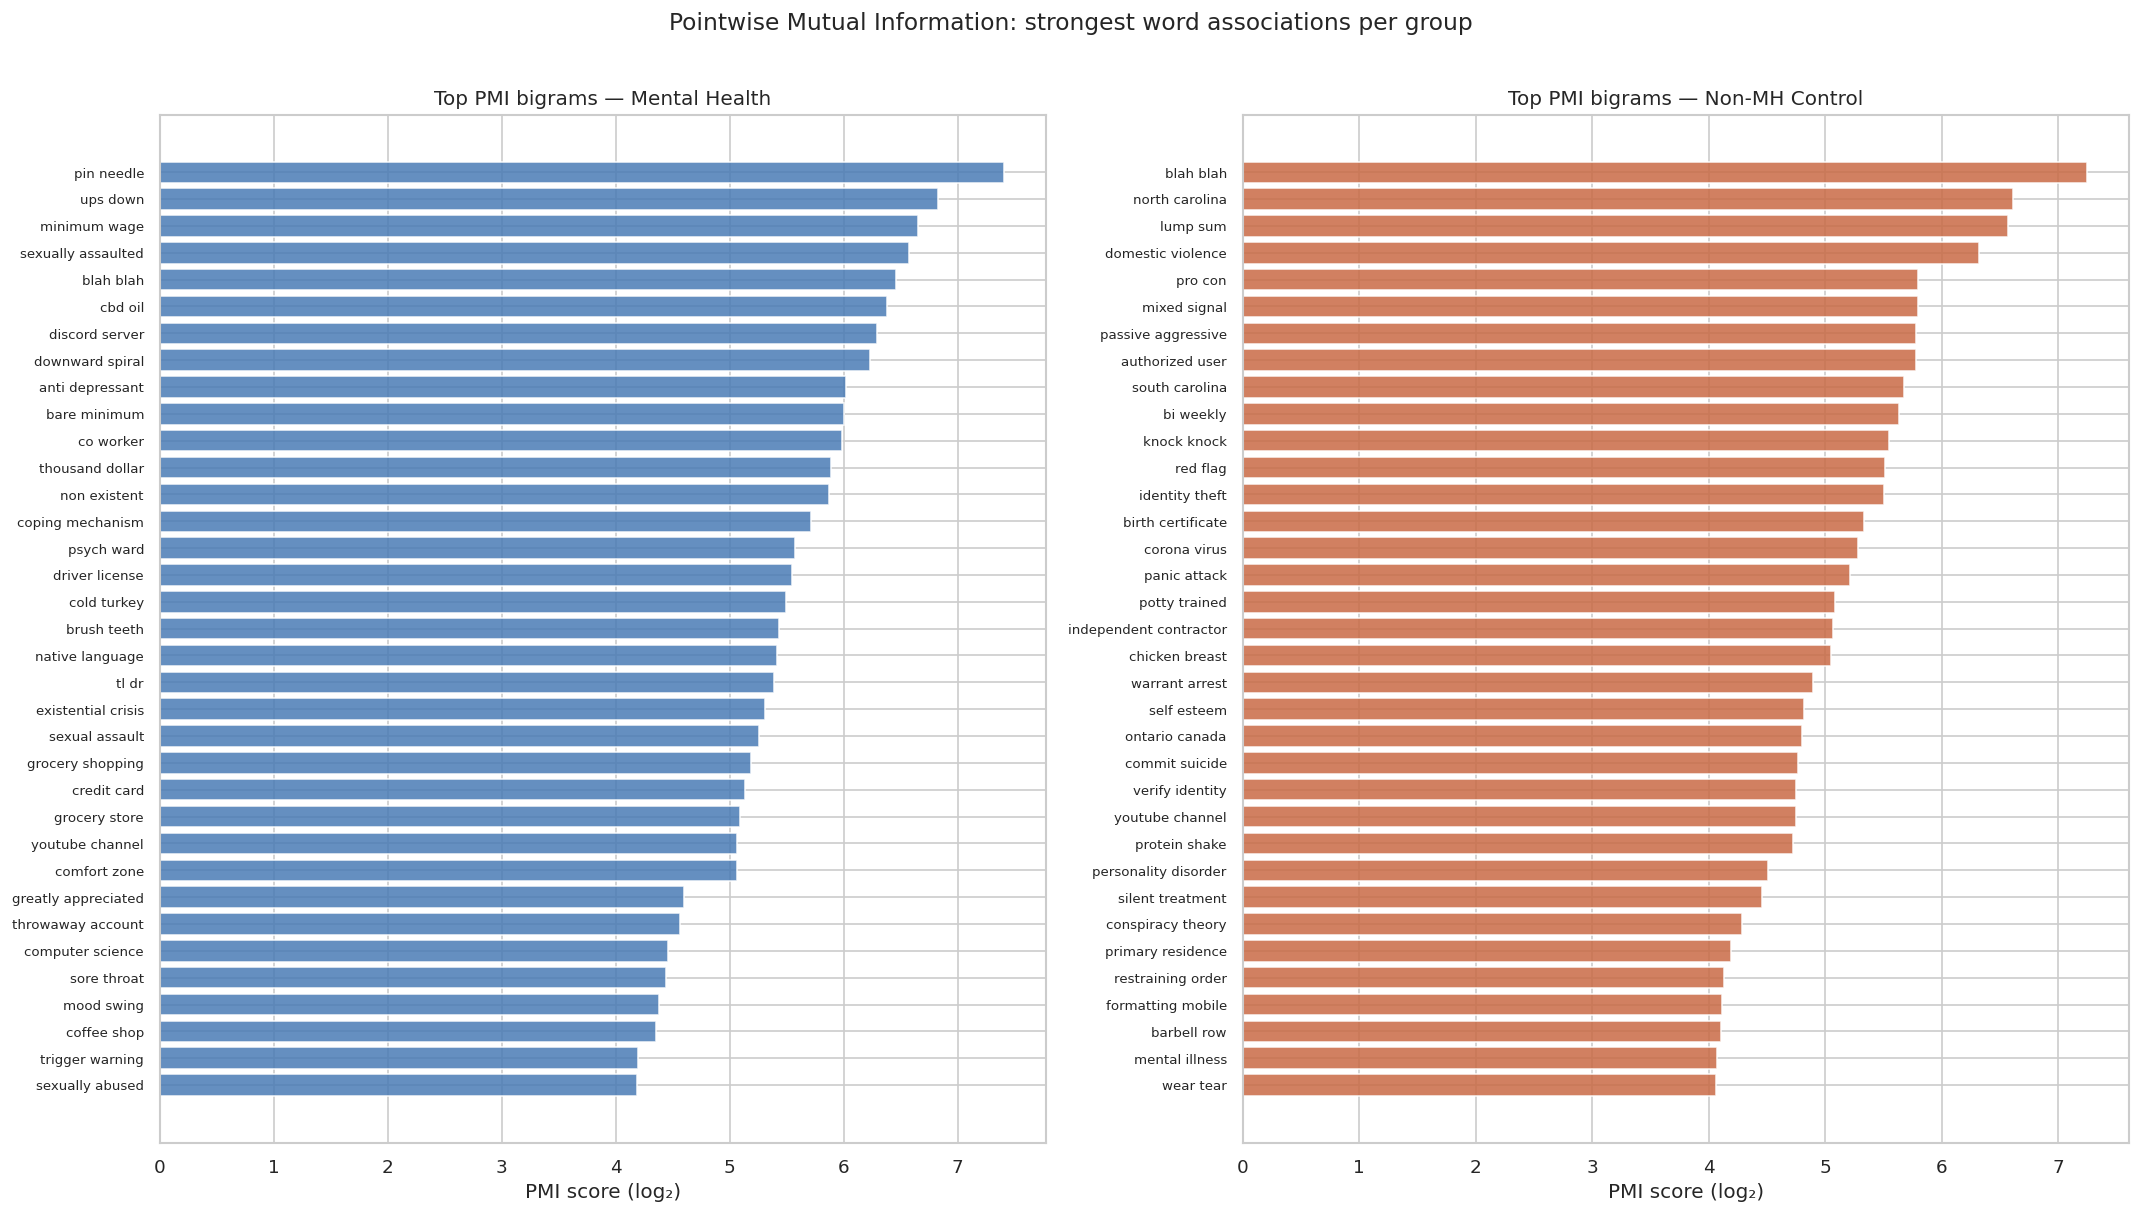

In [78]:
# ── S13: PMI bar charts ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for ax, pmi_df, label, color in [
    (axes[0], mh_pmi,    "Mental Health",  "#4A7BB5"),
    (axes[1], nonmh_pmi, "Non-MH Control", "#C96A45"),
]:
    ax.barh(pmi_df["bigram"][::-1], pmi_df["pmi"][::-1], color=color, alpha=0.85)
    ax.set_title(f"Top PMI bigrams — {label}", fontsize=12, fontweight="medium")
    ax.set_xlabel("PMI score (log₂)")
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Pointwise Mutual Information: strongest word associations per group", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s13_pmi_bar_charts.png", dpi=150, bbox_inches="tight")
plt.show()


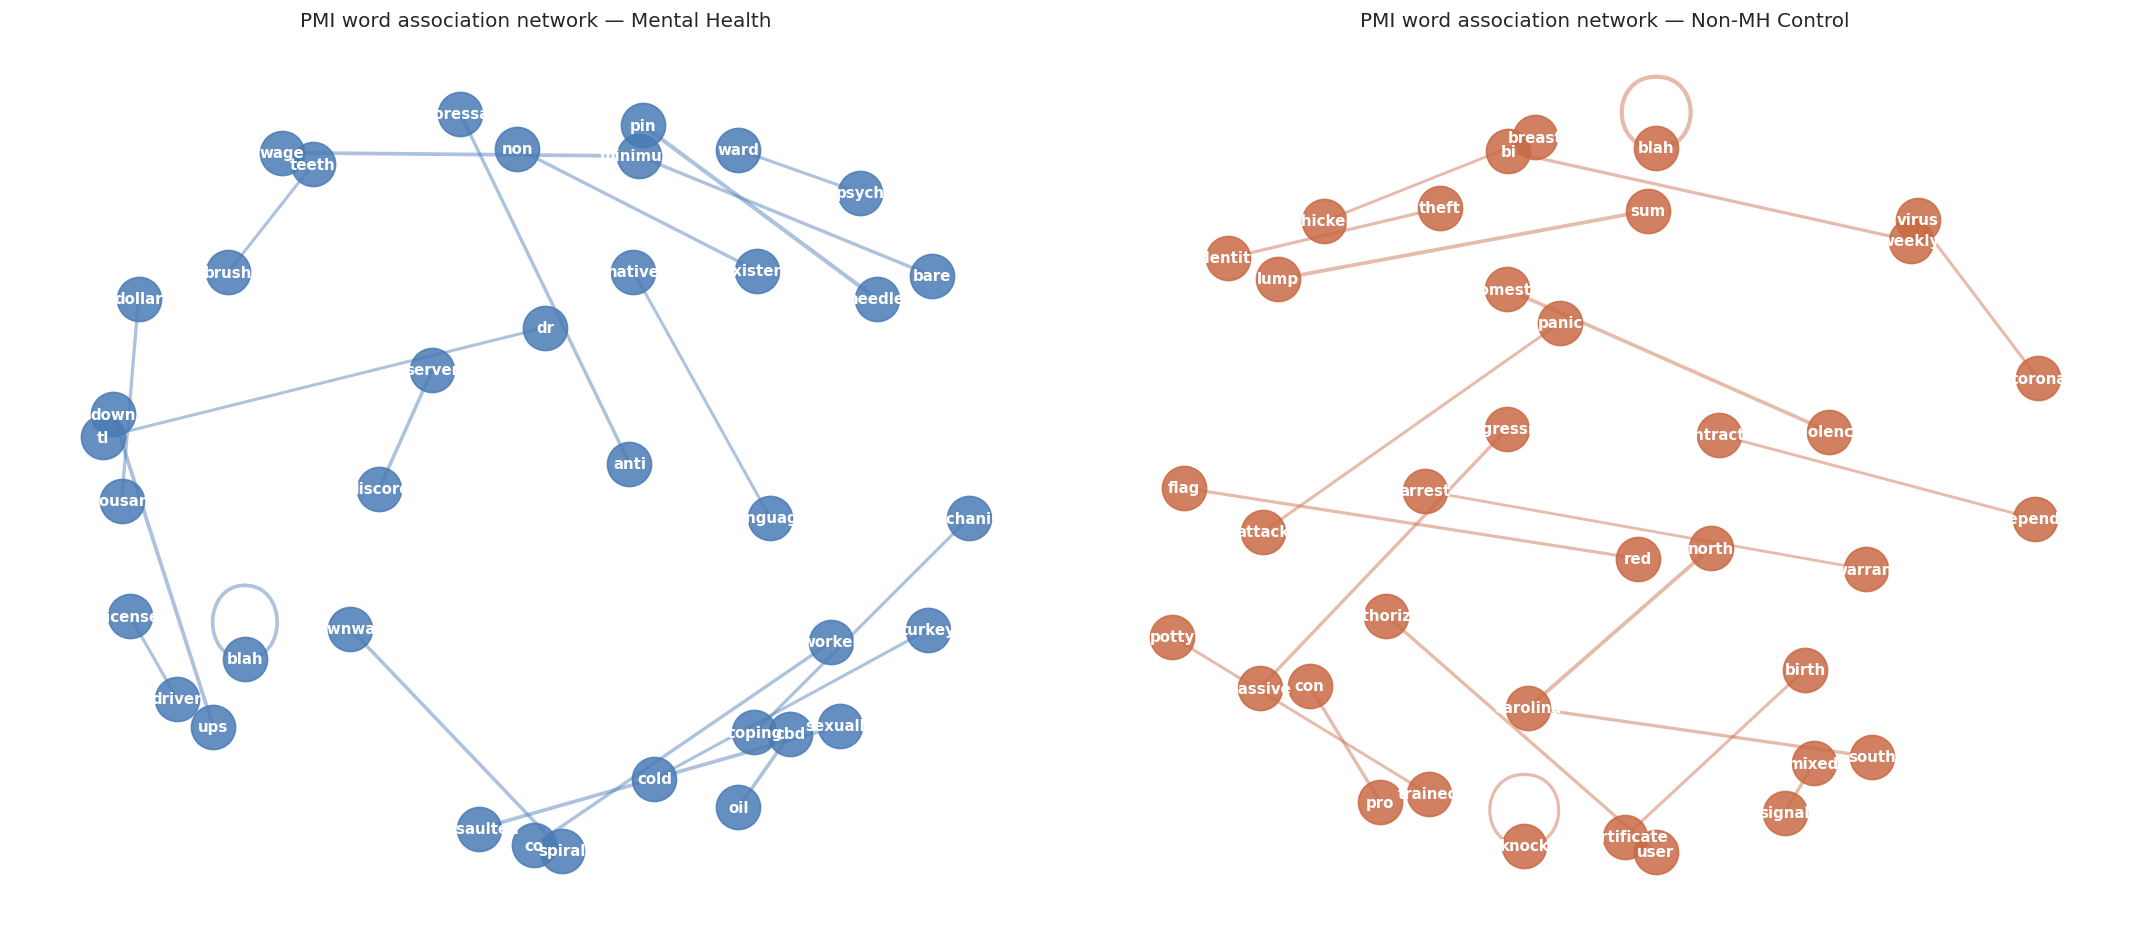

S13 artifacts saved.


In [79]:
# ── S13: PMI network graphs ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, pmi_df, label, color in [
    (axes[0], mh_pmi.head(20),    "Mental Health",  "#4A7BB5"),
    (axes[1], nonmh_pmi.head(20), "Non-MH Control", "#C96A45"),
]:
    G = nx.Graph()
    for _, row in pmi_df.iterrows():
        G.add_edge(row["w1"], row["w2"], weight=row["pmi"])

    pos = nx.spring_layout(G, seed=RANDOM_STATE, k=1.8)
    edge_w = [G[u][v]["weight"] for u, v in G.edges()]
    max_w  = max(edge_w) if edge_w else 1.0

    nx.draw_networkx_edges(G, pos, ax=ax,
                           width=[2.5 * w / max_w for w in edge_w],
                           alpha=0.45, edge_color=color)
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_size=700, node_color=color, alpha=0.85)
    nx.draw_networkx_labels(G, pos, ax=ax,
                            font_size=9, font_color="white", font_weight="bold")
    ax.set_title(f"PMI word association network — {label}", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "s13_pmi_networks.png", dpi=150, bbox_inches="tight")
plt.show()

pmi_export = pd.concat([
    mh_pmi.assign(group="mental_health"),
    nonmh_pmi.assign(group="non_mh"),
])
pmi_export.to_csv(ARTIFACT_DIR / "s13_pmi_pairs.csv", index=False)
print("S13 artifacts saved.")


## S14 — Artifact Export & Run Manifest

In [80]:
# ── S14: Collect all CSV artifacts and write manifest ────────────────────────
import datetime

csv_files     = sorted(ARTIFACT_DIR.glob("*.csv"))
manifest_rows = []

for f in csv_files:
    if f.stem == "s14_run_manifest":
        continue
    try:
        tmp = pd.read_csv(f)
        manifest_rows.append({
            "file_name":      f.name,
            "segment":        f.stem[:3].upper(),
            "row_count":      len(tmp),
            "column_count":   len(tmp.columns),
            "file_size_kb":   round(f.stat().st_size / 1024, 1),
            "generated_at":   datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        })
        del tmp
    except Exception as e:
        manifest_rows.append({"file_name": f.name, "error": str(e)})

manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(ARTIFACT_DIR / "s14_run_manifest.csv", index=False)

png_count = len(list(ARTIFACT_DIR.glob("*.png")))
csv_count = len(list(ARTIFACT_DIR.glob("*.csv")))
print(f"\nAdvanced EDA complete.")
print(f"  Output directory : {ARTIFACT_DIR}")
print(f"  CSV artifacts    : {csv_count}")
print(f"  PNG figures      : {png_count}")
print()
display(manifest_df)



Advanced EDA complete.
  Output directory : /content/drive/MyDrive/Data/processed/eda_artifacts/advanced_eda
  CSV artifacts    : 15
  PNG figures      : 29



,file_name,segment,row_count,column_count,file_size_kb,generated_at
0,s10_lda_topic_dist.csv,S10,49986,13,6588.8,2026-04-02 03:43:41
1,s10_lda_topic_words.csv,S10,150,4,2.8,2026-04-02 03:43:41
2,s11_cosine_delta_matrix.csv,S11,27,28,9.7,2026-04-02 03:43:41
3,s11_cosine_similarity_matrix.csv,S11,28,29,8.5,2026-04-02 03:43:41
4,s12_effect_sizes.csv,S12,12,6,0.7,2026-04-02 03:43:41
5,s12_temporal_signal_pivot.csv,S12,8,10,1.2,2026-04-02 03:43:41
6,s13_pmi_pairs.csv,S13,70,6,3.4,2026-04-02 03:43:41
7,s3_word_freq_by_group.csv,S3_,300,3,6.7,2026-04-02 03:43:41
8,s4_tfidf_distinctive_terms.csv,S4_,256,5,13.7,2026-04-02 03:43:41
9,s5_ngram_freq.csv,S5_,90,4,2.7,2026-04-02 03:43:41
